# Imports, Constants

In [24]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn import preprocessing
from IPython.display import display as iDisplay, Markdown, Latex
pd.options.mode.chained_assignment = None  # default='warn'

# Custom helper functions
from helpers import timestamp_to_unix_seconds as unix_seconds # Timestamps to Unix Seconds
from helpers import timestamp_to_unix_milliseconds as unix_milliseconds # Timestamps to Unix Milliseconds
le = preprocessing.LabelEncoder()

_FREQUENCY_BANDS = ['Theta','Alpha','Beta','Gamma']
_ELECTRODES = ['AF7','AF8']
_FREQUENCY_COLORS = ['red', 'blue', 'green', 'orange']
_GAZE_THRESHOLD = 250.0

_STATIC_OBJECTS = [
    'NorthSidewalk', 'SouthSidewalk',
    'NorthWalkingPole', 'NorthDiagonalPole', 'NorthWalkingSignal', 'NorthCarSignal',
    'SouthWalkingPole', 'SouthDiagonalPole', 'SouthWalkingSignal', 'SouthCarSignal',
    'RoadEast', 'RoadWest', 'RoadCrosswalk',
    'NE_Tree_10', 'NE_Tree_30', 'NE_Tree_50',
    'NW_Tree_10', 'NW_Tree_30', 'NW_Tree_50',
    'SE_Tree_10', 'SE_Tree_30', 'SE_Tree_50',
    'SW_Tree_10', 'SW_Tree_30', 'SW_Tree_50']
_DYNAMIC_OBJECTS = [
    'Car1-Detailed', 'Car2-Detailed', 'Car3-Detailed', 'Car4-Detailed', 'Car5-Detailed',
    'Sedan1-Detailed', 'Sedan2-Detailed', 'Sedan3-Detailed', 'Sedan4-Detailed', 'Sedan5-Detailed',
    'Jeep2-Detailed', 'Jeep3-Detailed', 'Jeep4-Detailed', 'Jeep5-Detailed',
    'SportCar1-Detailed', 'SportCar2-Detailed', 'SportCar3-Detailed', 'SportCar4-Detailed', 'SportCar5-Detailed',
    'MicroBus1-Detailed', 'MicroBus2-Detailed', 'MicroBus3-Detailed', 'MicroBus4-Detailed', 'MicroBus5-Detailed',
    'Truck1-Detailed',
    'HighMale2', 'LowMale2', 'HighFemale2', 'LowFemale2']

_OBJECT_TYPE_DICT = {
    'NorthSidewalk':'Sidewalk',
    'SouthSidewalk':'Sidewalk',
    'RoadEast':'Road',
    'RoadWest':'Road',
    'RoadCrosswalk':'Road',
    'NorthWalkingPole':'SignalPole',
    'NorthDiagonalPole':'SignalPole',
    'SouthWalkingPole':'SignalPole',
    'SouthDiagonalPole':'SignalPole',
    'NorthWalkingSignal':'PedestrianSignal',
    'SouthWalkingSignal':'PedestrianSignal',
    'NorthCarSignal':'VehicleSignal',
    'SouthCarSignal':'VehicleSignal',
    'NE_Tree_10':'Tree',
    'NE_Tree_30':'Tree',
    'NE_Tree_50':'Tree',
    'NW_Tree_10':'Tree',
    'NW_Tree_30':'Tree',
    'NW_Tree_50':'Tree',
    'SE_Tree_10':'Tree',
    'SE_Tree_30':'Tree',
    'SE_Tree_50':'Tree',
    'SW_Tree_10':'Tree',
    'SW_Tree_30':'Tree',
    'SW_Tree_50':'Tree',
    'Car1-Detailed':'Vehicle',
    'Car2-Detailed':'Vehicle',
    'Car3-Detailed':'Vehicle',
    'Car4-Detailed':'Vehicle',
    'Car5-Detailed':'Vehicle',
    'Sedan1-Detailed':'Vehicle',
    'Sedan2-Detailed':'Vehicle',
    'Sedan3-Detailed':'Vehicle',
    'Sedan4-Detailed':'Vehicle',
    'Sedan5-Detailed':'Vehicle',
    'Jeep2-Detailed':'Vehicle',
    'Jeep3-Detailed':'Vehicle',
    'Jeep4-Detailed':'Vehicle',
    'Jeep5-Detailed':'Vehicle',
    'SportCar1-Detailed':'Vehicle',
    'SportCar2-Detailed':'Vehicle',
    'SportCar3-Detailed':'Vehicle',
    'SportCar4-Detailed':'Vehicle',
    'SportCar5-Detailed':'Vehicle',
    'MicroBus1-Detailed':'Vehicle',
    'MicroBus2-Detailed':'Vehicle',
    'MicroBus3-Detailed':'Vehicle',
    'MicroBus4-Detailed':'Vehicle',
    'MicroBus5-Detailed':'Vehicle',
    'Truck1-Detailed':'Vehicle',
    'HighMale2':'Pedestrian',
    'LowMale2':'Pedestrian',
    'HighFemale2':'Pedestrian',
    'LowFemale2':'Pedestrian'
}
_OBJECT_TYPE_UNIQUE = set(_OBJECT_TYPE_DICT.values())

_OBJECT_STATE_DICT = {
    'NorthSidewalk':'Static',
    'SouthSidewalk':'Static',
    'RoadEast':'Static',
    'RoadWest':'Static',
    'RoadCrosswalk':'Static',
    'NorthWalkingPole':'Static',
    'NorthDiagonalPole':'Static',
    'SouthWalkingPole':'Static',
    'SouthDiagonalPole':'Static',
    'NorthWalkingSignal':'Static',
    'SouthWalkingSignal':'Static',
    'NorthCarSignal':'Static',
    'SouthCarSignal':'Static',
    'NE_Tree_10':'Static',
    'NE_Tree_30':'Static',
    'NE_Tree_50':'Static',
    'NW_Tree_10':'Static',
    'NW_Tree_30':'Static',
    'NW_Tree_50':'Static',
    'SE_Tree_10':'Static',
    'SE_Tree_30':'Static',
    'SE_Tree_50':'Static',
    'SW_Tree_10':'Static',
    'SW_Tree_30':'Static',
    'SW_Tree_50':'Static',
    'Car1-Detailed':'Dynamic',
    'Car2-Detailed':'Dynamic',
    'Car3-Detailed':'Dynamic',
    'Car4-Detailed':'Dynamic',
    'Car5-Detailed':'Dynamic',
    'Sedan1-Detailed':'Dynamic',
    'Sedan2-Detailed':'Dynamic',
    'Sedan3-Detailed':'Dynamic',
    'Sedan4-Detailed':'Dynamic',
    'Sedan5-Detailed':'Dynamic',
    'Jeep2-Detailed':'Dynamic',
    'Jeep3-Detailed':'Dynamic',
    'Jeep4-Detailed':'Dynamic',
    'Jeep5-Detailed':'Dynamic',
    'SportCar1-Detailed':'Dynamic',
    'SportCar2-Detailed':'Dynamic',
    'SportCar3-Detailed':'Dynamic',
    'SportCar4-Detailed':'Dynamic',
    'SportCar5-Detailed':'Dynamic',
    'MicroBus1-Detailed':'Dynamic',
    'MicroBus2-Detailed':'Dynamic',
    'MicroBus3-Detailed':'Dynamic',
    'MicroBus4-Detailed':'Dynamic',
    'MicroBus5-Detailed':'Dynamic',
    'Truck1-Detailed':'Dynamic',
    'HighMale2':'Dynamic',
    'LowMale2':'Dynamic',
    'HighFemale2':'Dynamic',
    'LowFemale2':'Dynamic'
}
_OBJECT_STATE_UNIQUE = set(_OBJECT_STATE_DICT.values())

_OBJECT_BLACKLIST = [
    'NorthSidewalk', 'SouthSidewalk',
    'NorthWalkingPole', 'NorthDiagonalPole',
    'SouthWalkingPole', 'SouthDiagonalPole',
    'RoadEast', 'RoadWest', 'RoadCrosswalk',
    'NE_Tree_10', 'NE_Tree_30', 'NE_Tree_50',
    'NW_Tree_10', 'NW_Tree_30', 'NW_Tree_50',
    'SE_Tree_10', 'SE_Tree_30', 'SE_Tree_50',
    'SW_Tree_10', 'SW_Tree_30', 'SW_Tree_50'
]

In [25]:
def LoadEEGCSV(src_filepath:str, drop_raw:bool=True, drop_accel:bool=True, drop_gyro:bool=True):
    df = pd.read_csv(src_filepath)
    df = df[~df['TimeStamp'].isna()] # Remove rows where timestamp is na
    df = df[~df['Battery'].isna()]   # Remove battery rows - useless
    df['unix_ms'] = df['TimeStamp'].apply(lambda x: int(unix_milliseconds(x))) # Convert from timestamp to unix ms
    
    drop_list = ['TimeStamp', 'Elements', 'Battery', 'HeadBandOn','AUX_RIGHT','AUX_LEFT','HSI_TP9','HSI_AF7','HSI_AF8','HSI_TP10']
    if drop_raw: drop_list.extend(['RAW_AF7','RAW_AF8','RAW_TP9','RAW_TP10'])
    if drop_accel: drop_list.extend(['Accelerometer_X','Accelerometer_Y','Accelerometer_Z'])
    if drop_gyro: drop_list.extend(['Gyro_X','Gyro_Y','Gyro_Z'])
    df.drop(columns=drop_list, inplace=True) # Drop useless columns
    
    # For each frequency, exit from log to actual power, then remove the older column
    for freq in _FREQUENCY_BANDS:
        for electrode in _ELECTRODES:
            in_colname = f'{freq}_{electrode}'
            out_colname = f'{in_colname}_Pow'
            df[out_colname] = 10 ** df[in_colname]
            df.drop(columns=[in_colname], inplace=True)
            df.rename(columns={out_colname:in_colname},inplace=True)
    
    return df

# 1. User Data Preprocessing

## 1a. Trial Data

In [54]:
def GetTrial(src_dir:str, verbose:bool=False, display_df:bool=False):
    # Read trials
    df = pd.read_csv(src_dir)
    
    # Get the initial endings, so that we can filter out some EEG data
    initial_end_frame = df.loc[0,'end_frame']
    initial_end_ts = df.loc[0,'end_timestamp']
    initial_end_unix_ms = df.loc[0,'end_unix']
    session_end_unix_ms = df.loc[8,'end_unix']
    
    # End of function
    if verbose:
        print('Initial End Frame:', initial_end_frame)
        print('Initial End Timestamp:', initial_end_ts)
        print('Initial End Unix MS:', initial_end_unix_ms)
        print('Session End Unix MS:', session_end_unix_ms)
    if display_df: display(df.head(10))
    return {
        'df':df,
        'initial_end_frame':initial_end_frame,
        'initial_end_ts':initial_end_ts,
        'initial_end_unix_ms':initial_end_unix_ms,
        'session_end_unix_ms':session_end_unix_ms
    }

In [55]:
iDisplay(Markdown('### _Example:_'))

trial_data = GetTrial(
    '../samples/P1/trials.csv', 
    verbose=True, 
    display_df=True
)

### _Example:_

Initial End Frame: 939
Initial End Timestamp: 20.01333
Initial End Unix MS: 1742844921602
Session End Unix MS: 1742845089786


,trial_number,car_congestion,start_unix,start_timestamp,start_frame,end_unix,end_timestamp,end_frame
0,0,NoCongestion,1742844904966,3.656917,263,1742844921602,20.01333,939
1,1,MinimalCongestion,1742844921605,20.013330,939,1742844939478,37.90667,2049
2,2,NoCongestion,1742844939478,37.906670,2049,1742844978617,77.01334,3953
3,3,MinimalCongestion,1742844978617,77.013340,3953,1742845018134,116.56000,6365
4,4,MinimalCongestion,1742845018135,116.560000,6365,1742845032997,131.40000,7051
5,5,NoCongestion,1742845032997,131.400000,7051,1742845049913,148.33330,8103
6,6,NoCongestion,1742845049914,148.333300,8103,1742845066703,165.10670,8878
7,7,MinimalCongestion,1742845066703,165.106700,8878,1742845077660,176.09330,9571
8,8,NoCongestion,1742845077660,176.093300,9571,1742845089786,188.18670,10150


## 1b. Rest EEG

In [28]:
# Load rest EEG, with basic filtering steps
def GetRest(src_dir:str, minUnix:int=10000, maxUnix:int=40000, display_df:bool=False):
    df = LoadEEGCSV(src_dir) 
    df['rel_unix_ms'] = df['unix_ms'] - df['unix_ms'].iloc[0]
    df = df[(df['rel_unix_ms']>=minUnix) & (df['rel_unix_ms']<=maxUnix)]
    
    if display_df: display(df.head(10))
    return df
    
 # Given a column, get the min and max (as a tuple) in that column
def GetRange(df, colname, verbose:bool=True):
    col = df[colname]
    colmin = col.min()
    colmax = col.max()
    
    if verbose: 
        print('Column Min:',colmin)
        print('Column Max:',colmax)
    return (colmin, colmax)

In [29]:
iDisplay(Markdown('### _Example:_'))

rest_df = GetRest('../samples/P1/eeg_rest.csv', display_df=True)
(theta_af7_min, theta_af7_max) = GetRange(rest_df, 'Theta_AF7')

### _Example:_

,Delta_TP9,Delta_AF7,Delta_AF8,Delta_TP10,Theta_TP9,Theta_TP10,Alpha_TP9,Alpha_TP10,Beta_TP9,Beta_TP10,...,unix_ms,Theta_AF7,Theta_AF8,Alpha_AF7,Alpha_AF8,Beta_AF7,Beta_AF8,Gamma_AF7,Gamma_AF8,rel_unix_ms
21,0.498901,-0.297020,-0.358144,0.314952,0.473056,0.311967,1.246834,0.613872,0.759605,0.431475,...,1742843742296,0.675274,0.768388,1.738451,0.657873,0.843034,0.596581,0.603524,0.332374,10070
22,0.308224,-0.400088,-0.293477,0.172084,0.322230,0.309353,1.060038,0.587880,0.694824,0.340091,...,1742843742787,0.807577,0.668221,1.550415,0.737787,0.621098,0.710872,0.635268,0.367052,10561
23,0.283378,-0.215677,-0.267583,0.130059,0.326667,0.214115,0.873031,0.411481,0.580001,0.185547,...,1742843743313,0.671022,0.705231,1.294999,0.737787,0.545276,0.737302,0.626439,0.396658,11087
24,0.554294,-0.180313,-0.263684,0.316392,0.424532,-0.031076,0.731718,0.241833,0.494207,0.094774,...,1742843743800,0.627473,0.411090,1.306643,1.040510,0.570119,0.630674,0.714041,0.431104,11574
25,0.894297,-0.166159,-0.500520,0.513242,0.909077,0.302420,1.172841,0.853984,0.515002,0.238165,...,1742843744301,0.582638,0.432557,1.294990,1.211859,0.839651,0.665985,0.660666,0.511799,12075
26,1.072450,-0.288636,-0.430350,0.521080,0.973839,0.525551,1.170154,0.858768,0.432453,0.266225,...,1742843744826,0.558182,0.503917,1.011536,1.208311,1.028214,0.705293,0.664733,0.466766,12600
27,1.106349,-0.357647,-0.353827,0.445011,1.001880,0.534553,1.173902,0.858768,0.419263,0.229370,...,1742843745319,0.736000,0.537968,1.038491,1.137670,1.175624,0.741554,0.646927,0.388093,13093
28,1.130574,-0.229333,-0.258709,0.193512,0.867345,0.400848,1.152100,0.794354,0.339285,0.141205,...,1742843745804,0.713012,0.475655,1.083191,1.078695,1.042611,0.687371,0.618143,0.247116,13578
29,0.814022,-0.309573,-0.086218,0.133933,0.550186,0.118281,0.616867,0.609366,0.413446,0.145344,...,1742843746287,0.678942,0.426361,1.293979,0.909238,0.900790,0.765024,0.564474,0.232951,14061
30,0.476056,-0.336204,-0.110206,0.212044,0.383493,0.204948,0.730346,0.622418,0.576041,0.073754,...,1742843746814,0.591391,0.364739,1.236738,0.909238,0.652561,0.631274,0.603799,0.348667,14588


Column Min: 0.25232584996339863
Column Max: 1.2732775462941088


## 1c. Positions

In [30]:
# Parse positions to get crossing onsets and player positions
def GetPositions(src_dir:str, minUnix:int, maxUnix:int, display_df:bool=False):
    df = pd.read_csv(src_dir)
    df['frame'] = df['frame'].astype('Int64')
    df = df[df['unix_ms'].between(minUnix, maxUnix)]
    
    if display_df: display(df.head(10))
    return df

# Get only player position
def GetPlayerPositions(positions_df, player_name='CenterEyeAnchor', display_df:bool=False):
    # Initialize df from existing df
    df = positions_df[positions_df['obj_name']==player_name]
    
    # Get player's speed
    df['time_diff'] = df['unix_ms'].diff() / 1000 # unix ms to sec
    df['displacement'] = np.sqrt((df['pos_x'].diff()**2) + (df['pos_z'].diff()**2))
    df['speed'] = df['displacement'] / df['time_diff']
        
    # Termination
    if display_df: display(df)
    return df

# Calculate moments of crossing
def GetCrossings(df, minZ=2.25, maxZ=7.75, display_df:bool=False):
    # Get and combine moments of moving along the road
    moving_df = df[df['pos_z'].between(minZ,maxZ)]
    moving_df['next_frame'] = moving_df['frame'].shift(-1)
    moving_df['frame_diff'] = moving_df['next_frame'] - moving_df['frame']
    moving_df['group'] = (moving_df['next_frame'] != moving_df['frame'] + 1).cumsum()
    moving_df = moving_df[moving_df['frame_diff']==1]
    
    # Crossings defined by combinin g disparate movement segments
    crossing_df = moving_df.groupby('group').agg(
        start_unix_ms=('unix_ms', 'first'),
        start_frame=('frame','first'),
        start_rel_sec=('rel_timestamp','first'),
        end_unix_ms=('unix_ms', 'last'),
        end_frame=('frame','last'),
        end_rel_sec=('rel_timestamp','last'),
        group=('group','first')
    )
        
    # Terminate
    if display_df: display(crossing_df.head(10))
    return crossing_df

In [31]:
iDisplay(Markdown('### _Example:_'))

"""
# Recall from an earlier code block:
  ex_initial_frame,
  ex_initial_ts, 
  ex_initial_unix, 
  ex_session_unix
"""

positions_df = GetPositions(
    '../samples/P1/positions.csv', 
    minUnix=ex_initial_unix, 
    maxUnix=ex_session_unix,
    display_df=True
)
crossings_df = GetCrossings(
    positions_df, 
    display_df=True
)

### _Example:_

,unix_ms,rel_timestamp,frame,obj_name,guid,pos_x,pos_y,pos_z,forward_x,forward_y,forward_z
4990,1742844921610,20.02772,939,HighMale2,29686,45.537500,0.025000,-0.763002,0.994221,0.000000,-1.073492e-01
4991,1742844921610,20.02772,939,CenterEyeAnchor,27386,-0.492327,1.689065,7.551715,-0.208621,-0.180690,9.611600e-01
4992,1742844921610,20.02772,939,LowFemale2,33854,39.417370,0.025000,11.297680,0.999998,0.000000,2.216399e-03
4993,1742844921610,20.02772,939,HighFemale2,33816,-38.035420,0.025000,-0.585532,-0.998348,0.000000,-5.746675e-02
4994,1742844921611,20.02772,939,LowMale2,28708,-48.210650,0.025000,13.550000,-1.000000,0.000000,1.360774e-04
4995,1742844921611,20.02772,939,MicroBus1-Detailed,27438,19.651160,0.000000,6.250000,-1.000000,0.000000,-1.192093e-07
4996,1742844921611,20.02772,939,Sedan5-Detailed,26908,-9.540837,0.000000,3.750000,1.000000,0.000000,-1.192093e-07
4997,1742844921633,20.05806,940,HighMale2,29686,45.577780,0.025000,-0.767865,0.994225,0.000000,-1.073161e-01
4998,1742844921633,20.05806,940,CenterEyeAnchor,27386,-0.493373,1.686212,7.582197,-0.210969,-0.172612,9.621314e-01
4999,1742844921633,20.05806,940,LowFemale2,33854,39.458460,0.025000,11.297020,0.999998,0.000000,2.245843e-03


,start_unix_ms,start_frame,start_rel_sec,end_unix_ms,end_frame,end_rel_sec,group
group,,,,,,,
2,1742844921611,939,20.02772,1742844921611,939,20.02772,2
4,1742844921634,940,20.05806,1742844921634,940,20.05806,4
6,1742844921662,941,20.08094,1742844921662,941,20.08094,6
8,1742844921688,942,20.10925,1742844921688,942,20.10925,8
10,1742844921716,943,20.13531,1742844921716,943,20.13531,10
12,1742844921745,944,20.16359,1742844921745,944,20.16359,12
14,1742844921773,945,20.19350,1742844921773,945,20.19350,14
15,1742844921801,946,20.22073,1742844921801,946,20.22073,15
16,1742844921829,947,20.24892,1742844921829,947,20.24892,16


## 1d. Eye, Gaze

In [32]:
def GetEyes(src_dir:str, minUnix:int, maxUnix:int, side='Left', obj_blacklist=None, display_df:bool=False):
    df = pd.read_csv(src_dir)
    df = df[(df['side']==side) & (df['unix_ms'].between(minUnix, maxUnix))]
    df['frame'] = df['frame'].astype('Int64')
    if obj_blacklist is not None: df = df[~df['target_name'].isin(obj_blacklist)]
    
    if display_df: display(df.head(10))
    return df

# Ensure that gaze targets are within the active environment
def RestrictGazePositions(eyes_df, positions_df, minX=-75, maxX=75, minZ=-13.625, maxZ=23.625, display_df:bool=False):
    eyepos_df = pd.merge(eyes_df, positions_df, left_on='target_name', right_on='obj_name', how='left')
    eyepos_df = eyepos_df[
        (eyepos_df['target_name'].isin(_STATIC_OBJECTS)) 
        | (
            (eyepos_df['pos_z'].between(minZ, maxZ))
            & (eyepos_df['pos_x'].between(minX, maxX))
        )
    ]
        
    # Drop irrelevant columns, clean up columns, and drop duplicates
    df = eyepos_df.drop(columns=['unix_ms_y','rel_timestamp_y','frame_y','obj_name','pos_x','pos_y','pos_z','forward_x','forward_y','forward_z','guid'])
    df.rename(columns={'unix_ms_x':'unix_ms','rel_timestamp_x':'rel_timestamp','frame_x':'frame'}, inplace=True)
    df.drop_duplicates(subset='unix_ms', keep="first", inplace=True)
    
    if display_df: display(df.head(10))
    return df
    
def GetGazeFromEyes(eye_df, gaze_threshold=250.0, display_df:bool=False):
    eye_df['target_name_group'] = (eye_df['target_name'] != eye_df['target_name'].shift()).cumsum()
    group_df = eye_df.groupby('target_name_group').agg(
        start_unix_ms=('unix_ms', 'first'),
        start_frame = ('frame','first'),
        end_unix_ms=('unix_ms', 'last'),
        end_frame=('frame','last'),
        target_name=('target_name', 'first')
    )
    group_df['duration_ms'] = group_df['end_unix_ms'] - group_df['start_unix_ms']
    group_df = group_df[~group_df['target_name'].isna()]
    group_df.reset_index(drop=True, inplace=True)
        
    # Create a new group column based on both the time difference and the target value
    group_df['next_start_unix_ms'] = group_df['start_unix_ms'].shift(-1)
    group_df['time_diff'] = group_df['next_start_unix_ms'] - group_df['end_unix_ms']
    group_col = [0]  # Start with the first group
    for i in range(0, len(group_df)-1):
        # Check if the time difference is within the threshold and the target is the same
        if group_df.loc[i, 'time_diff'] <= gaze_threshold and group_df.loc[i, 'target_name'] == group_df.loc[i+1 , 'target_name']:
            # If both conditions are met, group together (same group number as previous)
            group_col.append(group_col[-1])
        else:
            # Otherwise, create a new group (increment the group number)
            group_col.append(group_col[-1] + 1)
    group_df['group'] = group_col
    group_df.drop(columns=['next_start_unix_ms', 'time_diff'], inplace=True)
    df = group_df.groupby('group').agg(
        start_unix_ms=('start_unix_ms', 'first'),
        start_frame=('start_frame','first'),
        end_unix_ms=('end_unix_ms', 'last'),
        end_frame=('end_frame','last'),
        target_name=('target_name', 'first')
    )
    df['duration_ms'] = df['end_unix_ms'] - df['start_unix_ms']
    df.reset_index(drop=True, inplace=True)
        
    # Terminate
    if display_df: display(df.head(10))
    return df

In [33]:
iDisplay(Markdown('### _Example:_'))

"""
# Recall from an earlier code block:
  ex_initial_frame,
  ex_initial_ts, 
  ex_initial_unix, 
  ex_session_unix
"""

eyes_df = GetEyes('../samples/P1/eye.csv', ex_initial_unix, ex_session_unix, obj_blacklist=_OBJECT_BLACKLIST, display_df=True)
gaze_df = GetGazeFromEyes(eyes_df, display_df=True)

### _Example:_

,unix_ms,rel_timestamp,frame,event,side,screen_pos_x,screen_pos_y,screen_pos_z,target_name
1693,1742844922608,17.37367,975,NaN,Left,600.9084,785.2206,49.22567,NaN
1696,1742844922636,17.40146,976,NaN,Left,607.0247,785.0912,49.30114,NaN
1699,1742844922663,17.42809,977,NaN,Left,638.8970,780.1842,49.59785,NaN
1774,1742844923341,18.11563,1016,NaN,Left,633.6433,783.3610,49.61330,NaN
1777,1742844923370,18.14573,1018,NaN,Left,663.9325,781.6461,49.81992,NaN
1792,1742844923520,18.29522,1028,NaN,Left,778.0553,760.9371,49.76772,NaN
1795,1742844923549,18.32481,1030,NaN,Left,681.5686,758.9002,49.84408,NaN
1798,1742844923578,18.35474,1032,NaN,Left,674.2291,762.7234,49.82477,NaN
1801,1742844923607,18.38362,1034,NaN,Left,697.3862,754.5173,49.87755,NaN
1804,1742844923637,18.41197,1036,NaN,Left,725.4507,754.4977,49.90404,NaN


,start_unix_ms,start_frame,end_unix_ms,end_frame,target_name,duration_ms
0,1742844924032,1062,1742844924597,1094,MicroBus1-Detailed,565
1,1742844924992,1119,1742844924992,1119,Sedan5-Detailed,0
2,1742844925590,1159,1742844925590,1159,Sedan5-Detailed,0
3,1742844926412,1211,1742844927092,1252,MicroBus1-Detailed,680
4,1742844927108,1253,1742844927108,1253,Car2-Detailed,0
5,1742844927140,1255,1742844927191,1258,HighFemale2,51
6,1742844929165,1388,1742844929333,1396,Car2-Detailed,168
7,1742844929519,1405,1742844929629,1411,Sedan2-Detailed,110
8,1742844929697,1415,1742844929697,1415,Sedan4-Detailed,0
9,1742844929732,1417,1742844929801,1421,MicroBus1-Detailed,69


## 1e. Session EEG

In [34]:
def GetSessionEEG(src_dir:str, minUnix:int, maxUnix:int, display_df:bool=False):
    df = LoadEEGCSV(src_dir)
    df = df[df['unix_ms'].between(minUnix, maxUnix)]
    
    if display_df: display(df.head(10))
    return df

# Look through each frequency-electrode combo, generate normalized version
def NormalizeEEG(df, rest_df, bands, electrodes, display_df:bool=False):
    for freq in bands:
        for electrode in electrodes:
            in_colname = f'{freq}_{electrode}'
            out_colname = f'{in_colname}_normalized'
            (minValue, maxValue) = GetRange(rest_df, in_colname, False)
            df[out_colname] = (df[in_colname] - minValue) / (maxValue - minValue)
    if display_df: display(df.head(10))
    return df

# Helper Function: must return a dict with the new colnames
def GetGazeWindowEEGs(row, eeg, colnames):
    # Initialize return dict
    return_dict = {}
    # Get gaze target qualities
    return_dict['target_type'] = _OBJECT_TYPE_DICT[row['target_name']]
    return_dict['target_state'] = _OBJECT_STATE_DICT[row['target_name']]
    # For each freq_band column name, get the prior, during, and after windows
    prior = eeg[eeg['unix_ms'].between(row['start_unix_ms']-2000, row['start_unix_ms'])]
    during = eeg[eeg['unix_ms'].between(row['start_unix_ms']-1000, row['start_unix_ms']+1000)]
    after = eeg[eeg['unix_ms'].between(row['start_unix_ms'], row['start_unix_ms']+2000)]
    for col in colnames:
        return_dict[f'{col}-prior_avg'] = prior[f'{col}_normalized'].mean()
        return_dict[f'{col}-prior_max'] = prior[f'{col}_normalized'].max()
        return_dict[f'{col}-during_avg'] = during[f'{col}_normalized'].mean()
        return_dict[f'{col}-during_max'] = during[f'{col}_normalized'].max()
        return_dict[f'{col}-after_avg'] = after[f'{col}_normalized'].mean()
        return_dict[f'{col}-after_max'] = after[f'{col}_normalized'].max()
    return return_dict

# Combine gaze and EEG
def CombineGazeEEG(gaze_df, eeg_df, frequencies, electrodes, display_df:bool=False):
    # Generate column names that are important
    freq_band_colnames = []
    for freq in frequencies: 
        for electrode in electrodes:
            freq_band_colnames.append(f'{freq}_{electrode}')
    
    # Calculate EEG avg and max windows prior, during, and after onset of events
    applied_gaze_df = gaze_df.apply(lambda row: GetGazeWindowEEGs(row, eeg_df, freq_band_colnames), axis='columns', result_type='expand')
    gaze_eeg_df = pd.concat([gaze_df, applied_gaze_df], axis='columns')
    gaze_eeg_df.dropna(inplace=True)
    
    # Terminate
    if display_df: display(gaze_eeg_df.head(10))
    return gaze_eeg_df

In [35]:
iDisplay(Markdown('### _Example:_'))

"""
# Recall from an earlier code block:
  ex_initial_frame,
  ex_initial_ts, 
  ex_initial_unix, 
  ex_session_unix
"""

eeg_df = GetSessionEEG('../samples/P1/eeg_vr.csv', ex_initial_unix, ex_session_unix, display_df=True)
eeg_df = NormalizeEEG(eeg_df, rest_df, _FREQUENCY_BANDS, _ELECTRODES, display_df=True)
gaze_eeg_df = CombineGazeEEG(gaze_df, eeg_df, _FREQUENCY_BANDS, _ELECTRODES, display_df=True)

### _Example:_

,Delta_TP9,Delta_AF7,Delta_AF8,Delta_TP10,Theta_TP9,Theta_TP10,Alpha_TP9,Alpha_TP10,Beta_TP9,Beta_TP10,...,Gamma_TP10,unix_ms,Theta_AF7,Theta_AF8,Alpha_AF7,Alpha_AF8,Beta_AF7,Beta_AF8,Gamma_AF7,Gamma_AF8
87,1.366736,0.680286,1.105917,1.542858,1.074675,1.424260,0.861299,1.379777,0.582147,0.750607,...,0.264770,1742844921753,1.656541,7.598641,1.748825,9.482550,0.923755,1.359911,0.528055,0.505572
88,1.366736,0.544931,1.004700,1.514174,1.074675,1.439539,0.861299,1.319792,0.582147,0.712024,...,0.391919,1742844922253,2.472509,4.619325,2.384769,5.194655,0.908390,1.253802,0.561708,0.368824
89,1.366736,0.636282,0.930376,1.338750,1.074675,1.380759,0.861299,1.140598,0.582147,0.649213,...,0.451724,1742844922752,3.358034,9.843548,3.697966,6.419008,0.912906,1.337618,0.549347,0.546924
90,1.366736,0.511767,0.807102,1.023143,1.074675,1.176435,0.861299,1.132102,0.582147,0.570533,...,0.484693,1742844923261,4.496757,11.643524,4.497358,5.580582,0.884945,1.300544,0.470828,0.543401
91,1.366736,0.553720,0.702741,0.722191,1.074675,0.678832,0.861299,1.095476,0.582147,0.428500,...,0.336490,1742844923752,5.737761,11.163376,5.845242,4.698711,0.961838,1.187565,0.484184,0.525077
92,1.366736,0.447246,0.589768,0.728580,1.074675,0.709242,0.861299,1.163606,0.582147,0.465676,...,0.313888,1742844924253,7.007232,7.265604,5.844377,4.647687,1.009010,1.199255,0.467655,0.394121
93,1.366736,0.682016,0.754639,0.843297,1.074675,0.789013,0.861299,1.150964,0.582147,0.392081,...,0.252126,1742844924753,7.313622,6.309841,5.809139,4.263450,1.098880,1.153346,0.532666,0.413089
94,1.366736,0.999435,0.685728,0.978895,1.074675,0.919033,0.861299,1.063660,0.582147,0.433951,...,0.253171,1742844925254,8.785775,7.582177,3.504516,4.178582,1.199332,1.367803,0.412436,0.612201
95,1.366736,1.041575,0.617976,1.090357,1.074675,0.883014,0.861299,0.702510,0.582147,0.468556,...,0.414456,1742844925753,10.048039,8.415198,6.327808,4.940432,1.359187,1.650056,0.434577,0.898816
96,1.366736,0.933469,0.353593,1.158796,1.074675,0.791799,0.861299,0.170295,0.582147,0.580103,...,0.485000,1742844926258,9.355721,7.010966,6.327808,4.872540,1.437488,2.056248,0.455040,1.045613


,Delta_TP9,Delta_AF7,Delta_AF8,Delta_TP10,Theta_TP9,Theta_TP10,Alpha_TP9,Alpha_TP10,Beta_TP9,Beta_TP10,...,Gamma_AF7,Gamma_AF8,Theta_AF7_normalized,Theta_AF8_normalized,Alpha_AF7_normalized,Alpha_AF8_normalized,Beta_AF7_normalized,Beta_AF8_normalized,Gamma_AF7_normalized,Gamma_AF8_normalized
87,1.366736,0.680286,1.105917,1.542858,1.074675,1.424260,0.861299,1.379777,0.582147,0.750607,...,0.528055,0.505572,1.375399,8.552745,0.673603,6.549447,0.565447,1.297674,-0.089315,0.570587
88,1.366736,0.544931,1.004700,1.514174,1.074675,1.439539,0.861299,1.319792,0.582147,0.712024,...,0.561708,0.368824,2.174621,5.093290,1.092865,3.468387,0.542492,1.162890,-0.006784,0.284377
89,1.366736,0.636282,0.930376,1.338750,1.074675,1.380759,0.861299,1.140598,0.582147,0.649213,...,0.549347,0.546924,3.041973,11.159435,1.958623,4.348144,0.549239,1.269357,-0.037098,0.657135
90,1.366736,0.511767,0.807102,1.023143,1.074675,1.176435,0.861299,1.132102,0.582147,0.570533,...,0.470828,0.543401,4.157328,13.249492,2.485641,3.745694,0.507466,1.222264,-0.229657,0.649761
91,1.366736,0.553720,0.702741,0.722191,1.074675,0.678832,0.861299,1.095476,0.582147,0.428500,...,0.484184,0.525077,5.372864,12.691964,3.374267,3.112027,0.622344,1.078753,-0.196904,0.611409
92,1.366736,0.447246,0.589768,0.728580,1.074675,0.709242,0.861299,1.163606,0.582147,0.465676,...,0.467655,0.394121,6.616283,8.166037,3.373696,3.075364,0.692818,1.093602,-0.237440,0.337324
93,1.366736,0.682016,0.754639,0.843297,1.074675,0.789013,0.861299,1.150964,0.582147,0.392081,...,0.532666,0.413089,6.916386,7.056245,3.350465,2.799271,0.827084,1.035287,-0.078006,0.377024
94,1.366736,0.999435,0.685728,0.978895,1.074675,0.919033,0.861299,1.063660,0.582147,0.433951,...,0.412436,0.612201,8.358328,8.533628,1.831085,2.738289,0.977159,1.307699,-0.372859,0.793759
95,1.366736,1.041575,0.617976,1.090357,1.074675,0.883014,0.861299,0.702510,0.582147,0.468556,...,0.434577,0.898816,9.594688,9.500897,3.692410,3.285715,1.215982,1.666228,-0.318559,1.393635
96,1.366736,0.933469,0.353593,1.158796,1.074675,0.791799,0.861299,0.170295,0.582147,0.580103,...,0.455040,1.045613,8.916577,7.870362,3.692410,3.236932,1.332964,2.182190,-0.268376,1.700875


,start_unix_ms,start_frame,end_unix_ms,end_frame,target_name,duration_ms,target_type,target_state,Theta_AF7-prior_avg,Theta_AF7-prior_max,...,Gamma_AF7-during_avg,Gamma_AF7-during_max,Gamma_AF7-after_avg,Gamma_AF7-after_max,Gamma_AF8-prior_avg,Gamma_AF8-prior_max,Gamma_AF8-during_avg,Gamma_AF8-during_max,Gamma_AF8-after_avg,Gamma_AF8-after_max
0,1742844924032,1062,1742844924597,1094,MicroBus1-Detailed,565,Vehicle,Dynamic,3.686697,5.372864,...,-0.185502,-0.078006,-0.251716,-0.078006,0.550671,0.657135,0.493879,0.649761,0.725435,1.393635
1,1742844924992,1119,1742844924992,1119,Sedan5-Detailed,0,Vehicle,Dynamic,5.765716,6.916386,...,-0.251716,-0.078006,-0.241994,-0.008184,0.493879,0.649761,0.725435,1.393635,1.426667,1.818399
2,1742844925590,1159,1742844925590,1159,Sedan5-Detailed,0,Vehicle,Dynamic,6.815966,8.358328,...,-0.259450,-0.078006,-0.143282,0.021991,0.529879,0.793759,1.066323,1.700875,1.598836,1.818399
3,1742844926412,1211,1742844927092,1252,MicroBus1-Detailed,680,Vehicle,Dynamic,8.446495,9.594688,...,-0.143282,0.021991,0.328846,0.936728,1.066323,1.700875,1.598836,1.818399,1.516454,1.818399
4,1742844927108,1253,1742844927108,1253,Car2-Detailed,0,Vehicle,Dynamic,8.183380,9.594688,...,0.027570,0.364849,0.497632,0.936728,1.426667,1.818399,1.495114,1.818399,1.755866,2.776049
5,1742844927140,1255,1742844927191,1258,HighFemale2,51,Pedestrian,Dynamic,8.183380,9.594688,...,0.027570,0.364849,0.497632,0.936728,1.426667,1.818399,1.495114,1.818399,1.755866,2.776049
6,1742844929165,1388,1742844929333,1396,Car2-Detailed,168,Vehicle,Dynamic,3.700289,6.231596,...,0.689202,0.936728,0.433841,0.663033,1.755866,2.776049,2.712823,3.292088,2.410545,3.292088
7,1742844929519,1405,1742844929629,1411,Sedan2-Detailed,110,Vehicle,Dynamic,4.647535,6.319965,...,0.560231,0.666959,0.330952,0.490088,2.208280,3.292088,2.820394,3.292088,2.021616,2.996918
8,1742844929697,1415,1742844929697,1415,Sedan4-Detailed,0,Vehicle,Dynamic,4.647535,6.319965,...,0.560231,0.666959,0.330952,0.490088,2.208280,3.292088,2.820394,3.292088,2.021616,2.996918
9,1742844929732,1417,1742844929801,1421,MicroBus1-Detailed,69,Vehicle,Dynamic,4.647535,6.319965,...,0.560231,0.666959,0.330952,0.490088,2.208280,3.292088,2.820394,3.292088,2.021616,2.996918


## 1f. Combined Example

In [56]:
# Step 1: Read more about the Trial
trial_data = GetTrial('../samples/P1/trials.csv', verbose=True)

# Step 2: Learn from Resting
rest_df = GetRest('../samples/P1/eeg_rest.csv')

# Step 3: Read Positions, get Crossings
positions_df = GetPositions('../samples/P1/positions.csv', minUnix=trial_data['initial_end_unix_ms'], maxUnix=trial_data['session_end_unix_ms'])
crossings_df = GetCrossings(positions_df)

# Step 4: Read the Eyes, find the Gaze
eyes_df = GetEyes('../samples/P1/eye.csv', trial_data['initial_end_unix_ms'], trial_data['session_end_unix_ms'], obj_blacklist=_OBJECT_BLACKLIST)
gaze_df = GetGazeFromEyes(eyes_df)

# Step 5: Brain Wave EEG from Sessions
eeg_df = GetSessionEEG('../samples/P1/eeg_vr.csv', trial_data['initial_end_unix_ms'], trial_data['session_end_unix_ms'])
eeg_df = NormalizeEEG(eeg_df, rest_df, _FREQUENCY_BANDS, _ELECTRODES)
gaze_eeg_df = CombineGazeEEG(gaze_df, eeg_df, _FREQUENCY_BANDS, _ELECTRODES, display_df=True)


Initial End Frame: 939
Initial End Timestamp: 20.01333
Initial End Unix MS: 1742844921602
Session End Unix MS: 1742845089786


,start_unix_ms,start_frame,end_unix_ms,end_frame,target_name,duration_ms,target_type,target_state,Theta_AF7-prior_avg,Theta_AF7-prior_max,...,Gamma_AF7-during_avg,Gamma_AF7-during_max,Gamma_AF7-after_avg,Gamma_AF7-after_max,Gamma_AF8-prior_avg,Gamma_AF8-prior_max,Gamma_AF8-during_avg,Gamma_AF8-during_max,Gamma_AF8-after_avg,Gamma_AF8-after_max
0,1742844924032,1062,1742844924597,1094,MicroBus1-Detailed,565,Vehicle,Dynamic,3.686697,5.372864,...,-0.185502,-0.078006,-0.251716,-0.078006,0.550671,0.657135,0.493879,0.649761,0.725435,1.393635
1,1742844924992,1119,1742844924992,1119,Sedan5-Detailed,0,Vehicle,Dynamic,5.765716,6.916386,...,-0.251716,-0.078006,-0.241994,-0.008184,0.493879,0.649761,0.725435,1.393635,1.426667,1.818399
2,1742844925590,1159,1742844925590,1159,Sedan5-Detailed,0,Vehicle,Dynamic,6.815966,8.358328,...,-0.259450,-0.078006,-0.143282,0.021991,0.529879,0.793759,1.066323,1.700875,1.598836,1.818399
3,1742844926412,1211,1742844927092,1252,MicroBus1-Detailed,680,Vehicle,Dynamic,8.446495,9.594688,...,-0.143282,0.021991,0.328846,0.936728,1.066323,1.700875,1.598836,1.818399,1.516454,1.818399
4,1742844927108,1253,1742844927108,1253,Car2-Detailed,0,Vehicle,Dynamic,8.183380,9.594688,...,0.027570,0.364849,0.497632,0.936728,1.426667,1.818399,1.495114,1.818399,1.755866,2.776049
5,1742844927140,1255,1742844927191,1258,HighFemale2,51,Pedestrian,Dynamic,8.183380,9.594688,...,0.027570,0.364849,0.497632,0.936728,1.426667,1.818399,1.495114,1.818399,1.755866,2.776049
6,1742844929165,1388,1742844929333,1396,Car2-Detailed,168,Vehicle,Dynamic,3.700289,6.231596,...,0.689202,0.936728,0.433841,0.663033,1.755866,2.776049,2.712823,3.292088,2.410545,3.292088
7,1742844929519,1405,1742844929629,1411,Sedan2-Detailed,110,Vehicle,Dynamic,4.647535,6.319965,...,0.560231,0.666959,0.330952,0.490088,2.208280,3.292088,2.820394,3.292088,2.021616,2.996918
8,1742844929697,1415,1742844929697,1415,Sedan4-Detailed,0,Vehicle,Dynamic,4.647535,6.319965,...,0.560231,0.666959,0.330952,0.490088,2.208280,3.292088,2.820394,3.292088,2.021616,2.996918
9,1742844929732,1417,1742844929801,1421,MicroBus1-Detailed,69,Vehicle,Dynamic,4.647535,6.319965,...,0.560231,0.666959,0.330952,0.490088,2.208280,3.292088,2.820394,3.292088,2.021616,2.996918


# 2. Analysis

## 2a. Normality Assumption Test

_Important for some correlation tests like ANOVA, which assume normality of distribution._

In [37]:
def TestNormality_Omni(gaze_eeg_df, frequencies, electrodes, verbose:bool=True, display_distributions:bool=True, save_figname:str=None):
    # Generate column names that are important
    freq_band_colnames = []
    for freq in frequencies: 
        for electrode in electrodes:
            freq_band_colnames.append(f'{freq}_{electrode}')

    # Let's test for normality via a simple test
    if verbose:
        for col in freq_band_colnames:
            prior_colname = f"{col}-prior_avg"
            prior_x = gaze_eeg_df[prior_colname]
            prior_res = stats.normaltest(prior_x)

            # during_colname = f"{col}-during_avg"
            # during_x = gaze_eeg_df[during_colname]
            # during_res = stats.normaltest(during_x)

            after_colname = f"{col}-after_avg"
            after_x = gaze_eeg_df[after_colname]
            after_res = stats.normaltest(after_x)

            print(f"{col}: OMNIBUS NORMALITY")
            if prior_res.pvalue < 0.05: print("\t*PRIOR:", prior_res)
            else: print("\tPRIOR:", prior_res)
            # if during_res.pvalue < 0.05: print("\t*DURING:", during_res)
            # else: print("\tDURING:", during_res)
            if after_res.pvalue < 0.05: print("\t*AFTER:", after_res)
            else: print("\tAFTER:", after_res)

    # Let's test for normality by putting each band-electrode combo and their variations into a histogram
    fig, ax = plt.subplots(nrows=len(frequencies), ncols=len(electrodes))
    fig.set_figheight(15)
    fig.set_figwidth(15)
    fig.suptitle(f"Gaze Target EEG Distributions")
    
    for i in range(len(frequencies)):
        freq = frequencies[i]
        for j in range(len(electrodes)):
            electrode = electrodes[j]
            # prior
            prior_colname = f"{freq}_{electrode}-prior_avg"
            gaze_eeg_df.hist(column=prior_colname, ax=ax[i,j], color='blue', alpha=0.25)
            # during
            # during_colname = f"{freq}_{electrode}-during_avg"
            # gaze_eeg_df.hist(column=during_colname, ax=ax[i,j], color='green', alpha=0.25 )
            # after
            after_colname = f"{freq}_{electrode}-after_avg"
            gaze_eeg_df.hist(column=after_colname, ax=ax[i,j], color='red', alpha=0.25)
            
    plt.tight_layout()
    if save_figname is not None: plt.savefig(save_figname, bbox_inches="tight", pad_inches=0.1)
    if display_distributions: plt.show()
    plt.close()

def TestNormality_Shapiro(gaze_eeg_df, frequencies, electrodes, verbose:bool=True, display_distributions:bool=True, save_figname:str=None):
     # Generate column names that are important
    freq_band_colnames = []
    for freq in frequencies: 
        for electrode in electrodes:
            freq_band_colnames.append(f'{freq}_{electrode}')

    # Let's test for normality via a simple test
    if verbose:
        for col in freq_band_colnames:
            prior_colname = f"{col}-prior_avg"
            prior_x = gaze_eeg_df[prior_colname]
            prior_res = stats.shapiro(prior_x)

            # during_colname = f"{col}-during_avg"
            # during_x = gaze_eeg_df[during_colname]
            # during_res = stats.shapiro(during_x)

            after_colname = f"{col}-after_avg"
            after_x = gaze_eeg_df[after_colname]
            after_res = stats.shapiro(after_x)

            print(f"{col}: SHAPIRO NORMALITY")
            if prior_res.pvalue >= 0.05: print("\t*PRIOR:", prior_res)
            else: print("\tPRIOR:", prior_res)
            # if during_res.pvalue >= 0.05: print("\t*DURING:", during_res)
            # else: print("\tDURING:", during_res)
            if after_res.pvalue >= 0.05: print("\t*AFTER:", after_res)
            else: print("\tAFTER:", after_res)

    # Let's test for normality by putting each band-electrode combo and their variations into a histogram
    fig, ax = plt.subplots(nrows=len(frequencies), ncols=len(electrodes))
    fig.set_figheight(15)
    fig.set_figwidth(15)
    fig.suptitle(f"Gaze Target EEG Distributions")
    
    for i in range(len(frequencies)):
        freq = frequencies[i]
        for j in range(len(electrodes)):
            electrode = electrodes[j]
            # prior
            prior_colname = f"{freq}_{electrode}-prior_avg"
            gaze_eeg_df.hist(column=prior_colname, ax=ax[i,j], color='blue', alpha=0.25, label='Prior')
            # during
            # during_colname = f"{freq}_{electrode}-during_avg"
            # gaze_eeg_df.hist(column=during_colname, ax=ax[i,j], color='green', alpha=0.25 )
            # after
            after_colname = f"{freq}_{electrode}-after_avg"
            gaze_eeg_df.hist(column=after_colname, ax=ax[i,j], color='red', alpha=0.25, label='After')
            
    plt.tight_layout()
    if save_figname is not None: plt.savefig(save_figname, bbox_inches="tight", pad_inches=0.1)
    if display_distributions: plt.show()
    plt.close()

### _Example:_

Theta_AF7: SHAPIRO NORMALITY
	PRIOR: ShapiroResult(statistic=0.892918050289154, pvalue=5.7955903964845845e-11)
	AFTER: ShapiroResult(statistic=0.8634166121482849, pvalue=1.2321175980531396e-12)
Theta_AF8: SHAPIRO NORMALITY
	PRIOR: ShapiroResult(statistic=0.9563583135604858, pvalue=6.035361366230063e-06)
	AFTER: ShapiroResult(statistic=0.8525221347808838, pvalue=3.431013611242262e-13)
Alpha_AF7: SHAPIRO NORMALITY
	PRIOR: ShapiroResult(statistic=0.904059648513794, pvalue=2.9811200730200937e-10)
	AFTER: ShapiroResult(statistic=0.898333728313446, pvalue=1.266148852430149e-10)
Alpha_AF8: SHAPIRO NORMALITY
	PRIOR: ShapiroResult(statistic=0.9199930429458618, pvalue=3.895094025097023e-09)
	AFTER: ShapiroResult(statistic=0.9264461398124695, pvalue=1.2084458766992157e-08)
Beta_AF7: SHAPIRO NORMALITY
	PRIOR: ShapiroResult(statistic=0.8527704477310181, pvalue=3.529868996925145e-13)
	AFTER: ShapiroResult(statistic=0.8753081560134888, pvalue=5.399793893273719e-12)
Beta_AF8: SHAPIRO NORMALITY
	PRIOR:

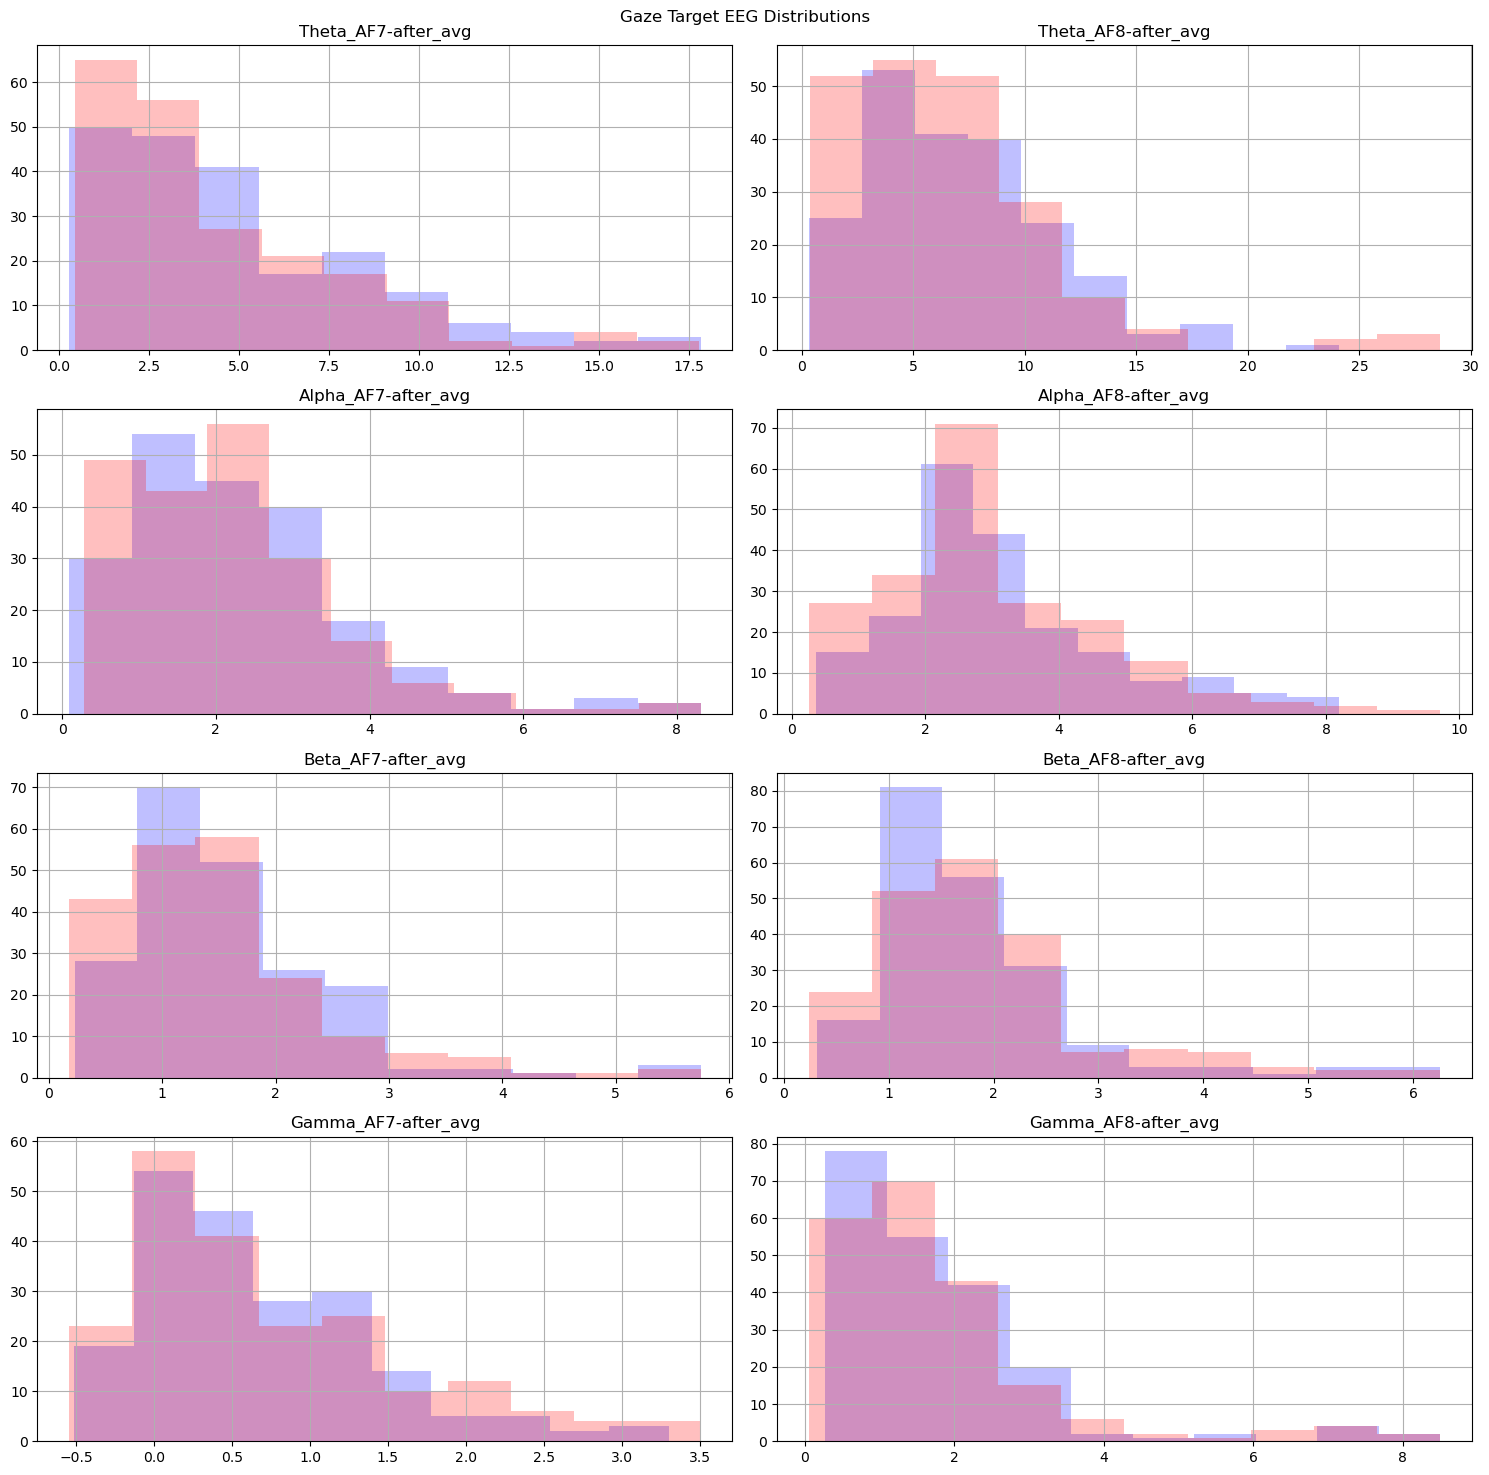

In [38]:
iDisplay(Markdown('### _Example:_'))

TestNormality_Shapiro(
    gaze_eeg_df, 
    _FREQUENCY_BANDS, 
    _ELECTRODES, 
    display_distributions=True, 
    save_figname=os.path.join('../samples/P1/distributions.png')
)

## 2b. Statistical Tests

In [39]:
def OneWayAnova_TargetType(df, eeg_column, verbose:bool=True):
    f_stat, p_value = stats.f_oneway(
        df[df['target_type'] == 'VehicleSignal'][eeg_column],
        df[df['target_type'] == 'PedestrianSignal'][eeg_column],
        df[df['target_type'] == 'SignalPole'][eeg_column],
        df[df['target_type'] == 'Vehicle'][eeg_column],
        df[df['target_type'] == 'Pedestrian'][eeg_column],
        df[df['target_type'] == 'Road'][eeg_column],
        df[df['target_type'] == 'Tree'][eeg_column],
        df[df['target_type'] == 'Sidewalk'][eeg_column]
    )
    if verbose:
        if p_value < 0.05:
            print(f'*{eeg_column}','\t f-statistic:',f_stat,'\t p-value:',p_value)
        else:
            print(f'{eeg_column}','\t f-statistic:',f_stat,'\t p-value:',p_value)

def OneWayAnova_TargetState(df, eeg_column, verbose:bool=True):
    f_stat, p_value = stats.f_oneway(
        df[df['target_state'] == 'Static'][eeg_column],
        df[df['target_state'] == 'Dynamic'][eeg_column]
    )
    if verbose:
        if p_value < 0.05:
            print(f'*{eeg_column}','\t f-statistic:',f_stat,'\t p-value:',p_value)
        else:
            print(f'{eeg_column}','\t f-statistic:',f_stat,'\t p-value:',p_value)

# We assume that the provided categorical column is biserial (aka only contains 'yes'-vs-'no', 0-or-1 values)
def PointsBiserial(df, eeg_column, categorical_column, verbose:bool=True):
    encoding_column = f'{categorical_column}_encoding'
    df[encoding_column] = le.fit_transform(df[categorical_column])
    res = stats.pointbiserialr(df[eeg_column], df[encoding_column])
    if verbose:
        if res.pvalue < 0.05: print(f'*{eeg_column}','\t statistic:',res.statistic,'\t p-value:',res.pvalue)
        else: print(f'{eeg_column}','\t statistic:',res.statistic,'\t p-value:',res.pvalue)
            
# We assume that the provided encoding column is NOT simply split between 0 and 1.
# We separate unique values in the categorical column into separate columns, then perform points biserial on each
def PointsPolyserial(df, eeg_column, categorical_column, verbose:bool=True):
    df_dummies = pd.get_dummies(df[categorical_column])
    df_new = pd.concat([df, df_dummies], axis=1)
    
    output_string = ''
    for dummy_col in df_dummies.columns:
        res = stats.pointbiserialr(df_new[eeg_column], df_new[dummy_col])
        if verbose:
            if res.pvalue < 0.05: output_string += f'|{dummy_col}|{res.statistic}|{res.pvalue}|*|\n'
            else: output_string += f'|{dummy_col}|{res.statistic}|{res.pvalue}||\n'
    iDisplay(Markdown(f'--- **{eeg_column}** ---\n|Target Type|Statistic|PValue|Significant?|\n|:-|:-:|:-:|:-:|\n'+output_string))

In [40]:
iDisplay(Markdown('### _Example:_'))

freq_band_colnames = []
for freq in _FREQUENCY_BANDS: 
    for electrode in _ELECTRODES:
        freq_band_colnames.append(f'{freq}_{electrode}')

"""
iDisplay(Markdown("**One Way ANOVA: Target Types:**"))
for col in freq_band_colnames:
    OneWayAnova_TargetType(gaze_eeg_df, f'{col}-prior_avg')
    OneWayAnova_TargetType(gaze_eeg_df, f'{col}-after_avg')

iDisplay(Markdown("**One Way ANOVA: Target States:**"))
for col in freq_band_colnames:
    OneWayAnova_TargetState(gaze_eeg_df, f'{col}-prior_avg')
    OneWayAnova_TargetState(gaze_eeg_df, f'{col}-after_avg')
"""

#iDisplay(Markdown("**Points Polyserial: Target Types:**"))
for col in freq_band_colnames:
    PointsPolyserial(gaze_eeg_df, f'{col}-prior_avg', 'target_type')
    PointsPolyserial(gaze_eeg_df, f'{col}-after_avg', 'target_type')


### _Example:_

--- **Theta_AF7-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.15876690030241392|0.02264659838656494|*|
|PedestrianSignal|-0.11252232916430033|0.10733453359527485||
|Vehicle|0.0279972748134662|0.6895471815166542||
|VehicleSignal|-0.10320695241008862|0.13988222948631593||


--- **Theta_AF7-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.22865190058007182|0.0009473760779886196|*|
|PedestrianSignal|-0.0050253524840482445|0.9428494613392628||
|Vehicle|-0.1373367766307444|0.049010917714557886|*|
|VehicleSignal|-0.00824182862559498|0.9064046649630292||


--- **Theta_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.2078344340261022|0.002720827359820287|*|
|PedestrianSignal|-0.07295717836978287|0.2973420379936736||
|Vehicle|-0.04022944038015696|0.5658865248103181||
|VehicleSignal|-0.07826904871458693|0.2634590094330869||


--- **Theta_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.15069769950151732|0.030608908163063008|*|
|PedestrianSignal|-0.018179575647272822|0.7953577154881449||
|Vehicle|-0.023722558401064325|0.7350176361831944||
|VehicleSignal|-0.08530979833714895|0.2227685818363618||


...

--- **Beta_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.04903256319982441|0.4839969376331052||
|PedestrianSignal|0.0035968872686219506|0.9590776449809063||
|Vehicle|-0.10225542354093368|0.14359129007183005||
|VehicleSignal|0.17571672121447363|0.011525433843101672|*|


--- **Gamma_AF7-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.012678247976030047|0.856471896844714||
|PedestrianSignal|0.034471828563801585|0.6227904414904077||
|Vehicle|-0.006660448275730039|0.9243030918732963||
|VehicleSignal|-0.0014975853997792228|0.9829555995145735||


--- **Gamma_AF7-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.11961846988787746|0.08679436963159014||
|PedestrianSignal|0.03980238142738185|0.5700209598579804||
|Vehicle|-0.0720911348320837|0.30312887781622855||
|VehicleSignal|0.1733010689864474|0.012735510946902876|*|


--- **Gamma_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.08006821761006046|0.2526070236658395||
|PedestrianSignal|-0.04190292616819534|0.5498244174829335||
|Vehicle|0.0701850270657508|0.31612545551571963||
|VehicleSignal|0.00023307638844757015|0.9973471028729256||


--- **Gamma_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.08779337014868484|0.20954091577125109||
|PedestrianSignal|-0.04166530336488436|0.5520914707681038||
|Vehicle|-0.062438371901836744|0.3726200125174342||
|VehicleSignal|0.18336954074946016|0.008333727251579751|*|


## 2c. Combined Example

Theta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=42.67132841027308, pvalue=5.420492751087323e-10)
	*AFTER: NormaltestResult(statistic=58.15958931578977, pvalue=2.3485815520046726e-13)
Theta_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=21.77248338722468, pvalue=1.8713943062708195e-05)
	*AFTER: NormaltestResult(statistic=94.1035093498657, pvalue=3.678600121127277e-21)
Alpha_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=59.54545260117916, pvalue=1.1745439074081041e-13)
	*AFTER: NormaltestResult(statistic=65.32682278441364, pvalue=6.523199671367816e-15)
Alpha_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=33.764657971106885, pvalue=4.6569082319188396e-08)
	*AFTER: NormaltestResult(statistic=42.24999638385591, pvalue=6.691598190173472e-10)
Beta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=99.51676358502037, pvalue=2.45589253534073e-22)
	*AFTER: NormaltestResult(statistic=79.14307642549048, pvalue=6.520776481795669e-18)
Bet

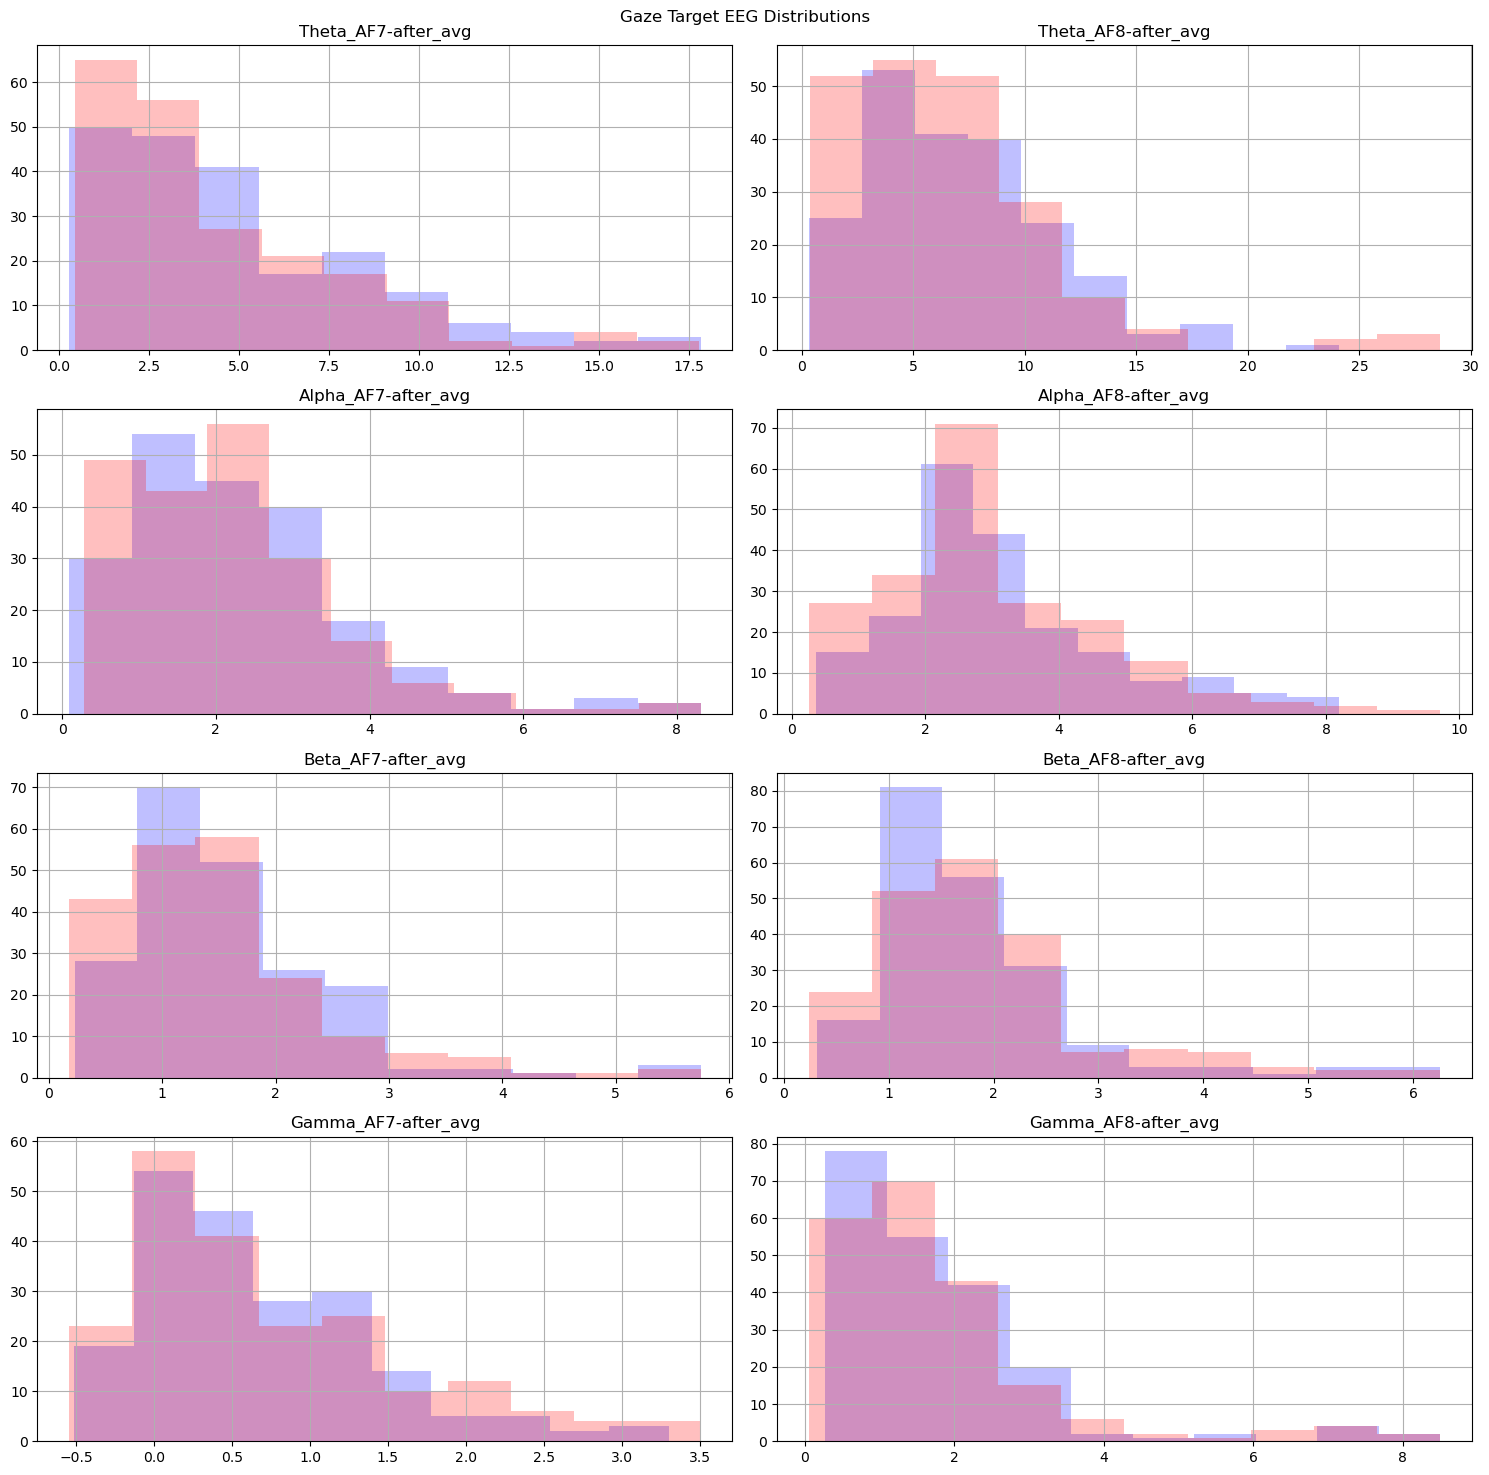

**Points Bilateral: Target Types:**

--- **Theta_AF7-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.15876690030241392|0.02264659838656494|*|
|PedestrianSignal|-0.11252232916430033|0.10733453359527485||
|Vehicle|0.0279972748134662|0.6895471815166542||
|VehicleSignal|-0.10320695241008862|0.13988222948631593||


--- **Theta_AF7-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.22865190058007182|0.0009473760779886196|*|
|PedestrianSignal|-0.0050253524840482445|0.9428494613392628||
|Vehicle|-0.1373367766307444|0.049010917714557886|*|
|VehicleSignal|-0.00824182862559498|0.9064046649630292||


--- **Theta_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.2078344340261022|0.002720827359820287|*|
|PedestrianSignal|-0.07295717836978287|0.2973420379936736||
|Vehicle|-0.04022944038015696|0.5658865248103181||
|VehicleSignal|-0.07826904871458693|0.2634590094330869||


--- **Theta_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.15069769950151732|0.030608908163063008|*|
|PedestrianSignal|-0.018179575647272822|0.7953577154881449||
|Vehicle|-0.023722558401064325|0.7350176361831944||
|VehicleSignal|-0.08530979833714895|0.2227685818363618||


...

--- **Beta_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.04903256319982441|0.4839969376331052||
|PedestrianSignal|0.0035968872686219506|0.9590776449809063||
|Vehicle|-0.10225542354093368|0.14359129007183005||
|VehicleSignal|0.17571672121447363|0.011525433843101672|*|


--- **Gamma_AF7-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.012678247976030047|0.856471896844714||
|PedestrianSignal|0.034471828563801585|0.6227904414904077||
|Vehicle|-0.006660448275730039|0.9243030918732963||
|VehicleSignal|-0.0014975853997792228|0.9829555995145735||


--- **Gamma_AF7-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.11961846988787746|0.08679436963159014||
|PedestrianSignal|0.03980238142738185|0.5700209598579804||
|Vehicle|-0.0720911348320837|0.30312887781622855||
|VehicleSignal|0.1733010689864474|0.012735510946902876|*|


--- **Gamma_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.08006821761006046|0.2526070236658395||
|PedestrianSignal|-0.04190292616819534|0.5498244174829335||
|Vehicle|0.0701850270657508|0.31612545551571963||
|VehicleSignal|0.00023307638844757015|0.9973471028729256||


--- **Gamma_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.08779337014868484|0.20954091577125109||
|PedestrianSignal|-0.04166530336488436|0.5520914707681038||
|Vehicle|-0.062438371901836744|0.3726200125174342||
|VehicleSignal|0.18336954074946016|0.008333727251579751|*|


In [41]:
TestNormality_Omni(gaze_eeg_df, _FREQUENCY_BANDS, _ELECTRODES, 
              display_distributions=True, save_figname=os.path.join('../samples/P1/distributions.png'))

freq_band_colnames = []
for freq in _FREQUENCY_BANDS: 
    for electrode in _ELECTRODES:
        freq_band_colnames.append(f'{freq}_{electrode}')
    
"""
iDisplay(Markdown("**One Way ANOVA: Target Types:**"))
for col in freq_band_colnames:
    OneWayAnova_TargetType(gaze_eeg_df, f'{col}-prior_avg')
    OneWayAnova_TargetType(gaze_eeg_df, f'{col}-after_avg')
iDisplay(Markdown("**One Way ANOVA: Target States:**"))
for col in freq_band_colnames:
    OneWayAnova_TargetState(gaze_eeg_df, f'{col}-prior_avg')
    OneWayAnova_TargetState(gaze_eeg_df, f'{col}-after_avg')
"""

iDisplay(Markdown("**Points Bilateral: Target Types:**"))
for col in freq_band_colnames:
    PointsPolyserial(gaze_eeg_df, f'{col}-prior_avg', 'target_type')
    PointsPolyserial(gaze_eeg_df, f'{col}-after_avg', 'target_type')


# 3. Aggregate Participant Parsing

In [78]:
freq_band_colnames = []
for freq in _FREQUENCY_BANDS: 
    for electrode in _ELECTRODES:
        freq_band_colnames.append(f'{freq}_{electrode}')
        
def ProcessParticipant(pdir:str, calculate_results:bool=True):
    
    iDisplay(Markdown(f'## Processing {pdir}'))
    
    # Step 1: Read more about the Trial
    trial_data = GetTrial(
        os.path.join(pdir,'trials.csv'), 
        verbose=True )
        
    # Step 2: Learn from Resting
    rest_df = GetRest(
        os.path.join(pdir, 'eeg_rest.csv') )
    
    # Step 3: Read Positions, get Crossings 
    positions_df = GetPositions(
        os.path.join(pdir, 'positions.csv'), 
        minUnix=trial_data['initial_end_unix_ms'], 
        maxUnix=trial_data['session_end_unix_ms'] )
    crossings_df = GetCrossings(
        positions_df )

    # Step 4: Read the Eyes, find the Gaze
    eyes_df = GetEyes(
        os.path.join(pdir, 'eye.csv'), 
        trial_data['initial_end_unix_ms'], 
        trial_data['session_end_unix_ms'],
        obj_blacklist=_OBJECT_BLACKLIST
    )
    gaze_df = GetGazeFromEyes(
        eyes_df )

    # Step 5: Brain Wave EEG from Sessions
    eeg_df = GetSessionEEG(
        os.path.join(pdir, 'eeg_vr.csv'), 
        trial_data['initial_end_unix_ms'], 
        trial_data['session_end_unix_ms'] )
    eeg_df = NormalizeEEG(
        eeg_df, 
        rest_df, 
        _FREQUENCY_BANDS, 
        _ELECTRODES )
    gaze_eeg_df = CombineGazeEEG(
        gaze_df, 
        eeg_df, 
        _FREQUENCY_BANDS, 
        _ELECTRODES )
    
    if calculate_results:
        # Step 6: Normality Assumption
        TestNormality_Omni(
            gaze_eeg_df, 
            _FREQUENCY_BANDS, 
            _ELECTRODES, 
            display_distributions=True, 
            save_figname=os.path.join(pdir, 'distributions.png') )

        # Step 7: Statistical Tests
        """
        iDisplay(Markdown("**One Way ANOVA: Target Types:**"))
        for col in freq_band_colnames:
            OneWayAnova_TargetType(gaze_eeg_df, f'{col}-prior_avg')
            OneWayAnova_TargetType(gaze_eeg_df, f'{col}-after_avg')
        iDisplay(Markdown("**One Way ANOVA: Target States:**"))
        for col in freq_band_colnames:
            OneWayAnova_TargetState(gaze_eeg_df, f'{col}-prior_avg')
            OneWayAnova_TargetState(gaze_eeg_df, f'{col}-after_avg')
        """
        
        iDisplay(Markdown("**Points Polyserial: Target Types:**"))
        for col in freq_band_colnames:
            PointsPolyserial(gaze_eeg_df, f'{col}-prior_avg', 'target_type')
            PointsPolyserial(gaze_eeg_df, f'{col}-after_avg', 'target_type')
    
    iDisplay(Markdown('---'))
    return {'eeg':eeg_df,'gaze_eeg':gaze_eeg_df,'trial':trial_data['df'],'crossings':crossings_df}

## Processing ../samples/P1

Initial End Frame: 939
Initial End Timestamp: 20.01333
Initial End Unix MS: 1742844921602
Session End Unix MS: 1742845089786
Theta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=42.67132841027308, pvalue=5.420492751087323e-10)
	*AFTER: NormaltestResult(statistic=58.15958931578977, pvalue=2.3485815520046726e-13)
Theta_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=21.77248338722468, pvalue=1.8713943062708195e-05)
	*AFTER: NormaltestResult(statistic=94.1035093498657, pvalue=3.678600121127277e-21)
Alpha_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=59.54545260117916, pvalue=1.1745439074081041e-13)
	*AFTER: NormaltestResult(statistic=65.32682278441364, pvalue=6.523199671367816e-15)
Alpha_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=33.764657971106885, pvalue=4.6569082319188396e-08)
	*AFTER: NormaltestResult(statistic=42.24999638385591, pvalue=6.691598190173472e-10)
Beta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=99.51676358

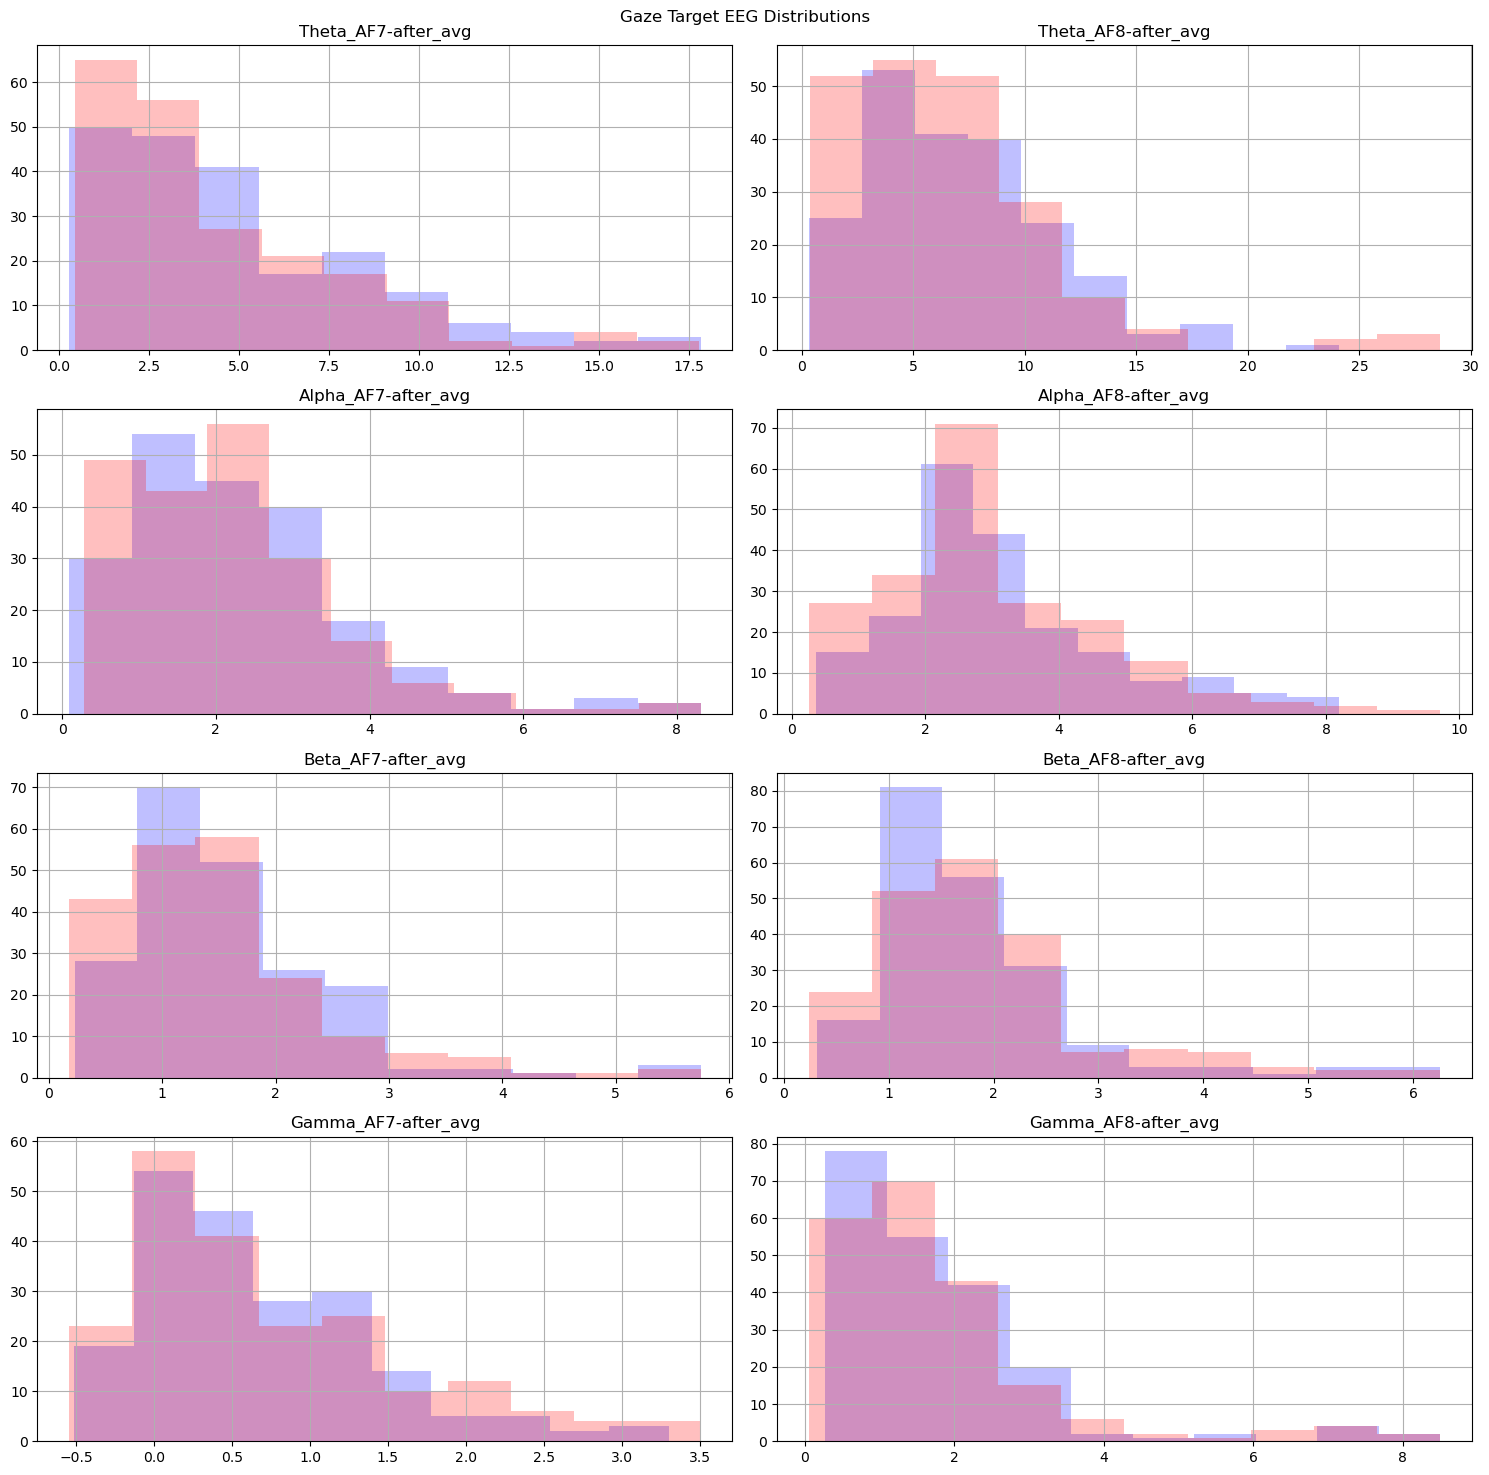

**Points Polyserial: Target Types:**

--- **Theta_AF7-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.15876690030241392|0.02264659838656494|*|
|PedestrianSignal|-0.11252232916430033|0.10733453359527485||
|Vehicle|0.0279972748134662|0.6895471815166542||
|VehicleSignal|-0.10320695241008862|0.13988222948631593||


--- **Theta_AF7-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.22865190058007182|0.0009473760779886196|*|
|PedestrianSignal|-0.0050253524840482445|0.9428494613392628||
|Vehicle|-0.1373367766307444|0.049010917714557886|*|
|VehicleSignal|-0.00824182862559498|0.9064046649630292||


--- **Theta_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.2078344340261022|0.002720827359820287|*|
|PedestrianSignal|-0.07295717836978287|0.2973420379936736||
|Vehicle|-0.04022944038015696|0.5658865248103181||
|VehicleSignal|-0.07826904871458693|0.2634590094330869||


--- **Theta_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.15069769950151732|0.030608908163063008|*|
|PedestrianSignal|-0.018179575647272822|0.7953577154881449||
|Vehicle|-0.023722558401064325|0.7350176361831944||
|VehicleSignal|-0.08530979833714895|0.2227685818363618||


...

--- **Gamma_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.08006821761006046|0.2526070236658395||
|PedestrianSignal|-0.04190292616819534|0.5498244174829335||
|Vehicle|0.0701850270657508|0.31612545551571963||
|VehicleSignal|0.00023307638844757015|0.9973471028729256||


--- **Gamma_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.08779337014868484|0.20954091577125109||
|PedestrianSignal|-0.04166530336488436|0.5520914707681038||
|Vehicle|-0.062438371901836744|0.3726200125174342||
|VehicleSignal|0.18336954074946016|0.008333727251579751|*|


---

## Processing ../samples/P3

Initial End Frame: 7537
Initial End Timestamp: 257.1467
Initial End Unix MS: 1742939590456
Session End Unix MS: 1742939915808
Theta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=96.96073618468145, pvalue=8.815433159277614e-22)
	*AFTER: NormaltestResult(statistic=51.76563204680939, pvalue=5.7442829608778264e-12)
Theta_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=111.02098966433564, pvalue=7.800068320403828e-25)
	*AFTER: NormaltestResult(statistic=72.11751800650559, pvalue=2.187156907476054e-16)
Alpha_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=41.938921482209935, pvalue=7.817698398828931e-10)
	*AFTER: NormaltestResult(statistic=20.668723155067312, pvalue=3.2497039095469555e-05)
Alpha_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=61.050278903876375, pvalue=5.534780175297136e-14)
	*AFTER: NormaltestResult(statistic=21.740994268397717, pvalue=1.9010917582853564e-05)
Beta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=25.202

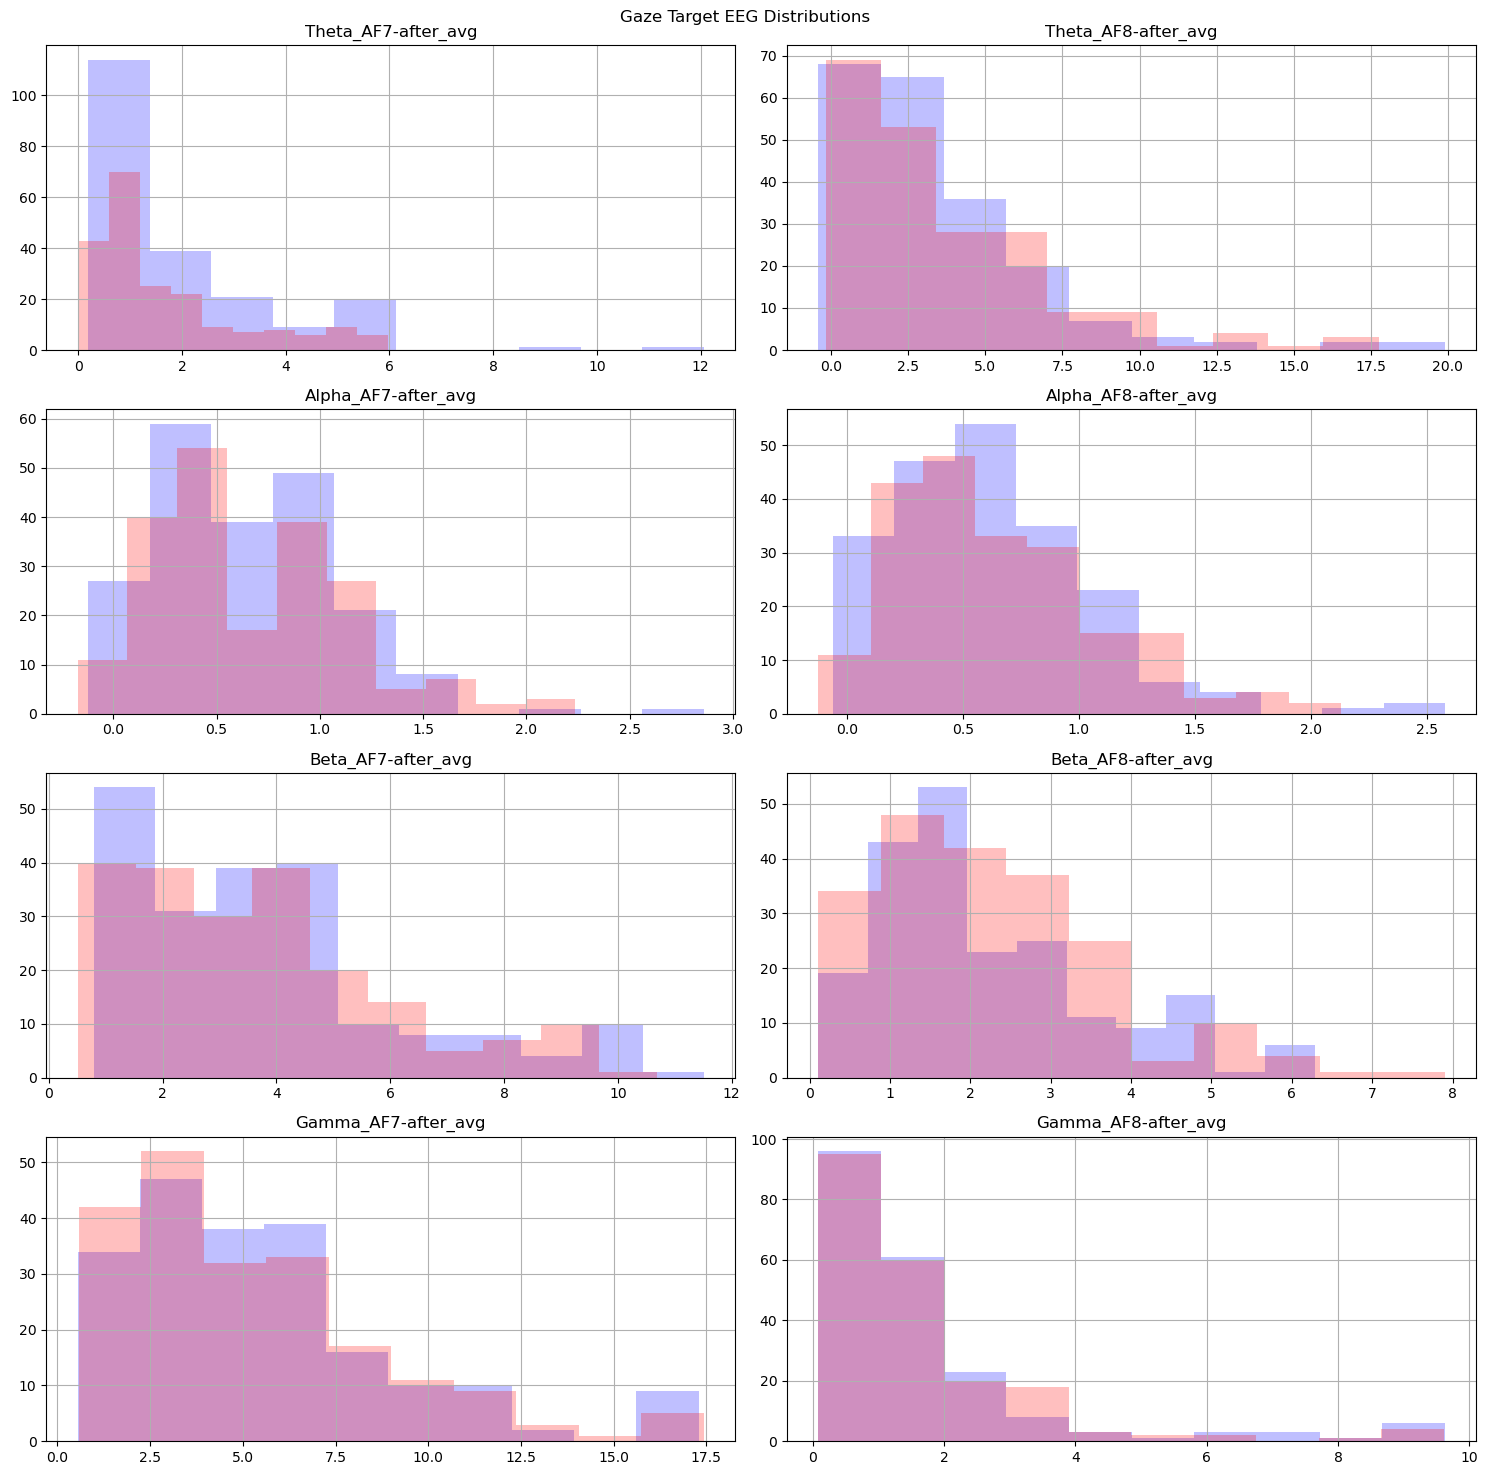

**Points Polyserial: Target Types:**

--- **Theta_AF7-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.09455578303932663|0.17747257860932356||
|PedestrianSignal|-0.10285608589649826|0.1422223884572318||
|Vehicle|0.1917397376145575|0.005885216722696356|*|
|VehicleSignal|-0.10064705239179567|0.1510355048720953||


--- **Theta_AF7-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.14456101742554245|0.0386383446317626|*|
|PedestrianSignal|0.10800466253091295|0.1232077575944453||
|Vehicle|0.09591052867509545|0.17131564963623258||
|VehicleSignal|-0.1354396676331052|0.05283408318581317||


--- **Theta_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.019025196958515882|0.7865769916418327||
|PedestrianSignal|0.0039089984261943805|0.9556394965139623||
|Vehicle|0.042828939760787194|0.5420292105573039||
|VehicleSignal|-0.05858341800307|0.40406979422663075||


--- **Theta_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.06611912269794953|0.34623142555009767||
|PedestrianSignal|0.17578173283229362|0.011699420147266016|*|
|Vehicle|-0.03630092520127388|0.6053360077702431||
|VehicleSignal|-0.07768078002965709|0.2682540096805864||


...

--- **Gamma_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.08468350740758238|0.22734008524776422||
|PedestrianSignal|-0.0841692432924106|0.23018533938805152||
|Vehicle|0.09727066889725983|0.16529532628640034||
|VehicleSignal|0.03215388400065882|0.6471846097650988||


--- **Gamma_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.1007730453810758|0.15052198979030862||
|PedestrianSignal|0.03419700347652446|0.6264177515977762||
|Vehicle|-0.03270351765715634|0.6415702288530772||
|VehicleSignal|0.13384079209665742|0.05572149399070141||


---

## Processing ../samples/P4

Initial End Frame: 2655
Initial End Timestamp: 67.34667
Initial End Unix MS: 1743003425106
Session End Unix MS: 1743003743345
Theta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=319.6739278586655, pvalue=3.834321822699996e-70)
	*AFTER: NormaltestResult(statistic=291.8415086090041, pvalue=4.240544357122435e-64)
Theta_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=131.25255451639887, pvalue=3.1540597691408425e-29)
	*AFTER: NormaltestResult(statistic=110.30745911704028, pvalue=1.1143961328754503e-24)
Alpha_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=107.60904468205948, pvalue=4.295293510533404e-24)
	*AFTER: NormaltestResult(statistic=109.53189149477616, pvalue=1.6422980064257865e-24)
Alpha_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=31.422419383045387, pvalue=1.5021327918224287e-07)
	*AFTER: NormaltestResult(statistic=79.47063575513923, pvalue=5.535676585298754e-18)
Beta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=43.25

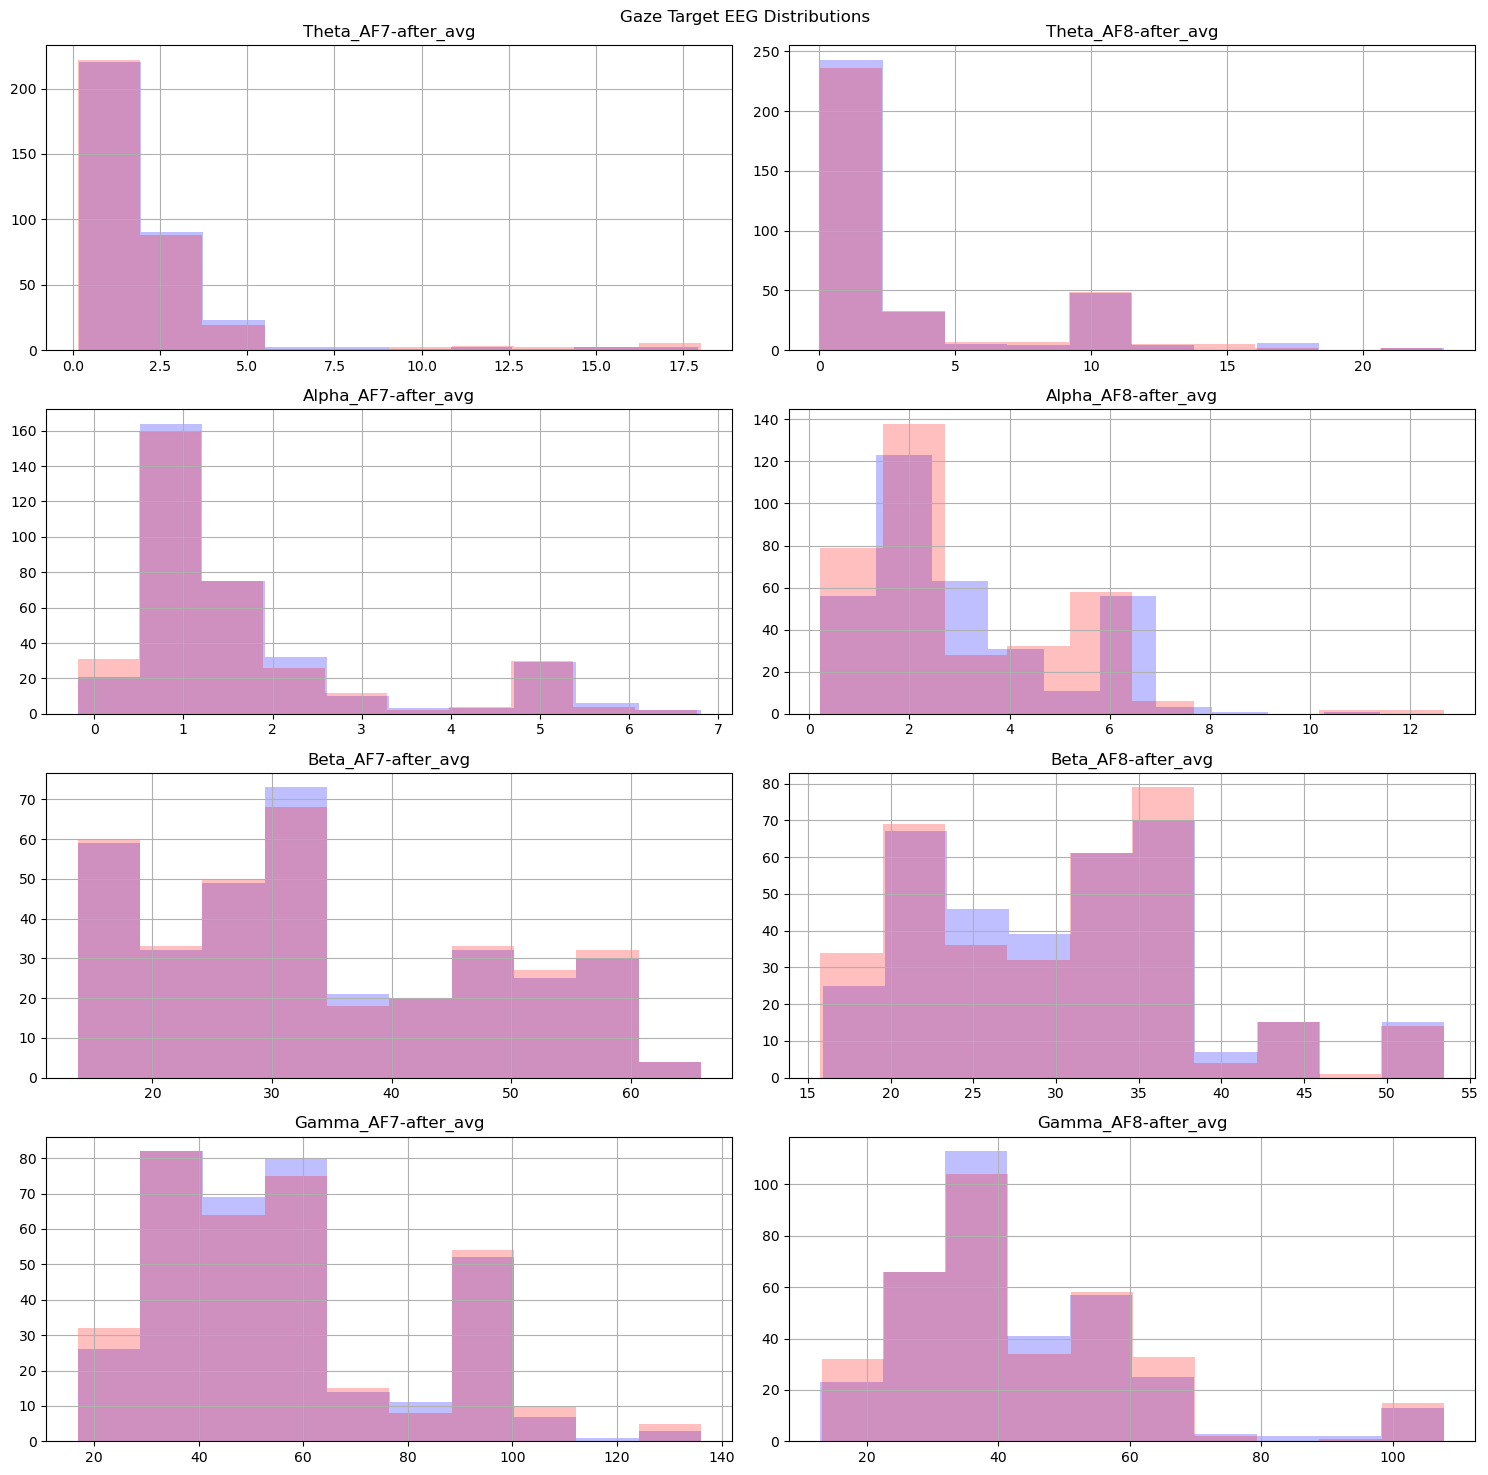

**Points Polyserial: Target Types:**

--- **Theta_AF7-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.05190219367886399|0.3364567890373798||
|PedestrianSignal|0.20771767486738965|0.00010163430025552977|*|
|Vehicle|-0.14767025864390185|0.0059963691004924526|*|
|VehicleSignal|-0.02944910550228636|0.5856669064989761||


--- **Theta_AF7-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.011827095178066467|0.8267365681204839||
|PedestrianSignal|0.14440692211653178|0.007218317125041812|*|
|Vehicle|-0.06006172703868414|0.2659004763009608||
|VehicleSignal|-0.0465440218312404|0.38877201171753933||


--- **Theta_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.0444949094748731|0.4100162940066848||
|PedestrianSignal|0.14781218171720517|0.005947710356173307|*|
|Vehicle|-0.07395118058084686|0.17053889021991617||
|VehicleSignal|-0.010438737914905943|0.8468081825823763||


--- **Theta_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.08132717377982467|0.1316566208684769||
|PedestrianSignal|0.07686499748907899|0.15426392706164593||
|Vehicle|0.02983715039726036|0.5807345222492354||
|VehicleSignal|-0.05908296442564568|0.27378359892388276||


...

--- **Gamma_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.08373664144366459|0.12056129360431751||
|PedestrianSignal|0.023934475009996892|0.6577561973962243||
|Vehicle|0.01677010990191972|0.7562702378987808||
|VehicleSignal|-0.09780914644539815|0.06960327790137505||


--- **Gamma_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.06529544907953937|0.22639446582538805||
|PedestrianSignal|0.047505139807528116|0.3790417812235988||
|Vehicle|-0.01925151895595123|0.7216036507102241||
|VehicleSignal|-0.06005904841986634|0.2659218358345878||


---

## Processing ../samples/P5

Initial End Frame: 1953
Initial End Timestamp: 54.64
Initial End Unix MS: 1743095004293
Session End Unix MS: 1743095199084
Theta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=50.94802449291589, pvalue=8.645239904977798e-12)
	*AFTER: NormaltestResult(statistic=82.59814992784385, pvalue=1.1588831156600462e-18)
Theta_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=6.469805462533347, pvalue=0.03936403364358769)
	*AFTER: NormaltestResult(statistic=15.845833819765321, pvalue=0.0003623438591349495)
Alpha_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=116.3030482942969, pvalue=5.560501325734455e-26)
	*AFTER: NormaltestResult(statistic=58.266463990775, pvalue=2.226373911877918e-13)
Alpha_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=14.136846413321518, pvalue=0.0008515748085834217)
	*AFTER: NormaltestResult(statistic=45.182674177828375, pvalue=1.5442121438429944e-10)
Beta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=7.15178958792586

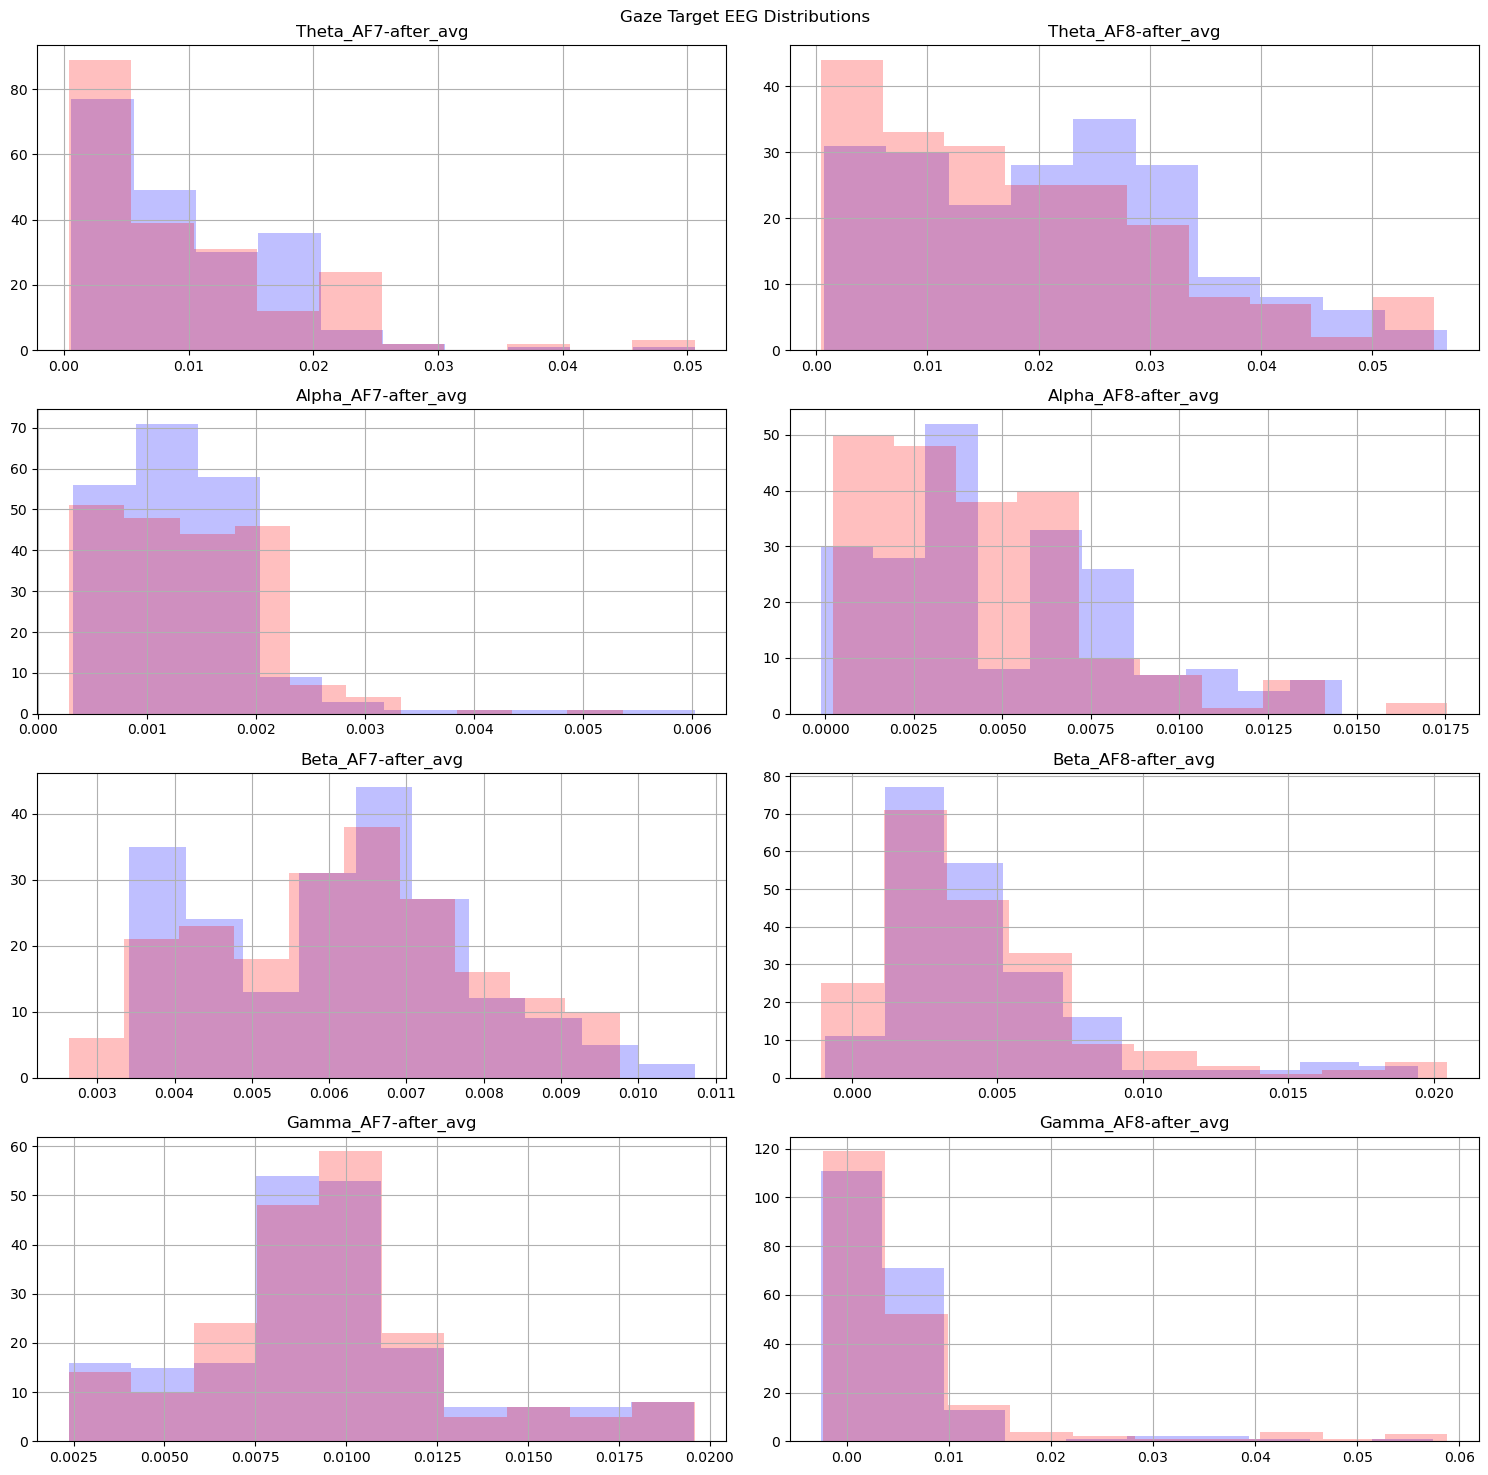

**Points Polyserial: Target Types:**

--- **Theta_AF7-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.040188017491877726|0.5701273862713078||
|PedestrianSignal|0.058074380299308295|0.411667365717996||
|Vehicle|-0.08945064833104624|0.20551941038431593||
|VehicleSignal|0.04140161786768639|0.5585296972735345||


--- **Theta_AF7-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.004363088727335023|0.9508601893204053||
|PedestrianSignal|0.06080972165782089|0.38995389480925813||
|Vehicle|-0.05098912162596499|0.47111673807055454||
|VehicleSignal|0.0011155536014244758|0.9874285665368517||


--- **Theta_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.022081000378767222|0.7551009812243932||
|PedestrianSignal|-0.012135096437765277|0.8639028801517964||
|Vehicle|0.0683132170911177|0.33403569553177986||
|VehicleSignal|-0.1418549443323735|0.04402832178704073|*|


--- **Theta_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.020186903394042867|0.7755228207306024||
|PedestrianSignal|0.022977890493964467|0.7454888433903512||
|Vehicle|0.08951352361076205|0.2051997105682439||
|VehicleSignal|-0.19130236744520884|0.006385904509875007|*|


...

--- **Gamma_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.038340936556184264|0.5879944357774683||
|PedestrianSignal|-0.011063534788410524|0.8758191468606278||
|Vehicle|0.047102047568686474|0.5056277959955785||
|VehicleSignal|-0.03298385941924847|0.641210961324154||


---

['Vehicle' 'Pedestrian' 'PedestrianSignal' 'VehicleSignal']


## Aggregate Results

Theta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=503.68015099313527, pvalue=4.2388191698419017e-110)
	*AFTER: NormaltestResult(statistic=575.8321532460033, pvalue=9.11248174689096e-126)
Theta_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=280.5483806481577, pvalue=1.2014153841744647e-61)
	*AFTER: NormaltestResult(statistic=385.2143673824474, pvalue=2.2478273338055397e-84)
Alpha_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=348.1136527177907, pvalue=2.559061804369494e-76)
	*AFTER: NormaltestResult(statistic=357.8449311585987, pvalue=1.9722433954253743e-78)
Alpha_AF8: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=149.1348221679917, pvalue=4.128429155268378e-33)
	*AFTER: NormaltestResult(statistic=250.0295486329777, pvalue=5.0906513968700445e-55)
Beta_AF7: OMNIBUS NORMALITY
	*PRIOR: NormaltestResult(statistic=148.19274185410367, pvalue=6.612336967960773e-33)
	*AFTER: NormaltestResult(statistic=151.30974950940455, pvalue=1.3915709851719212e-

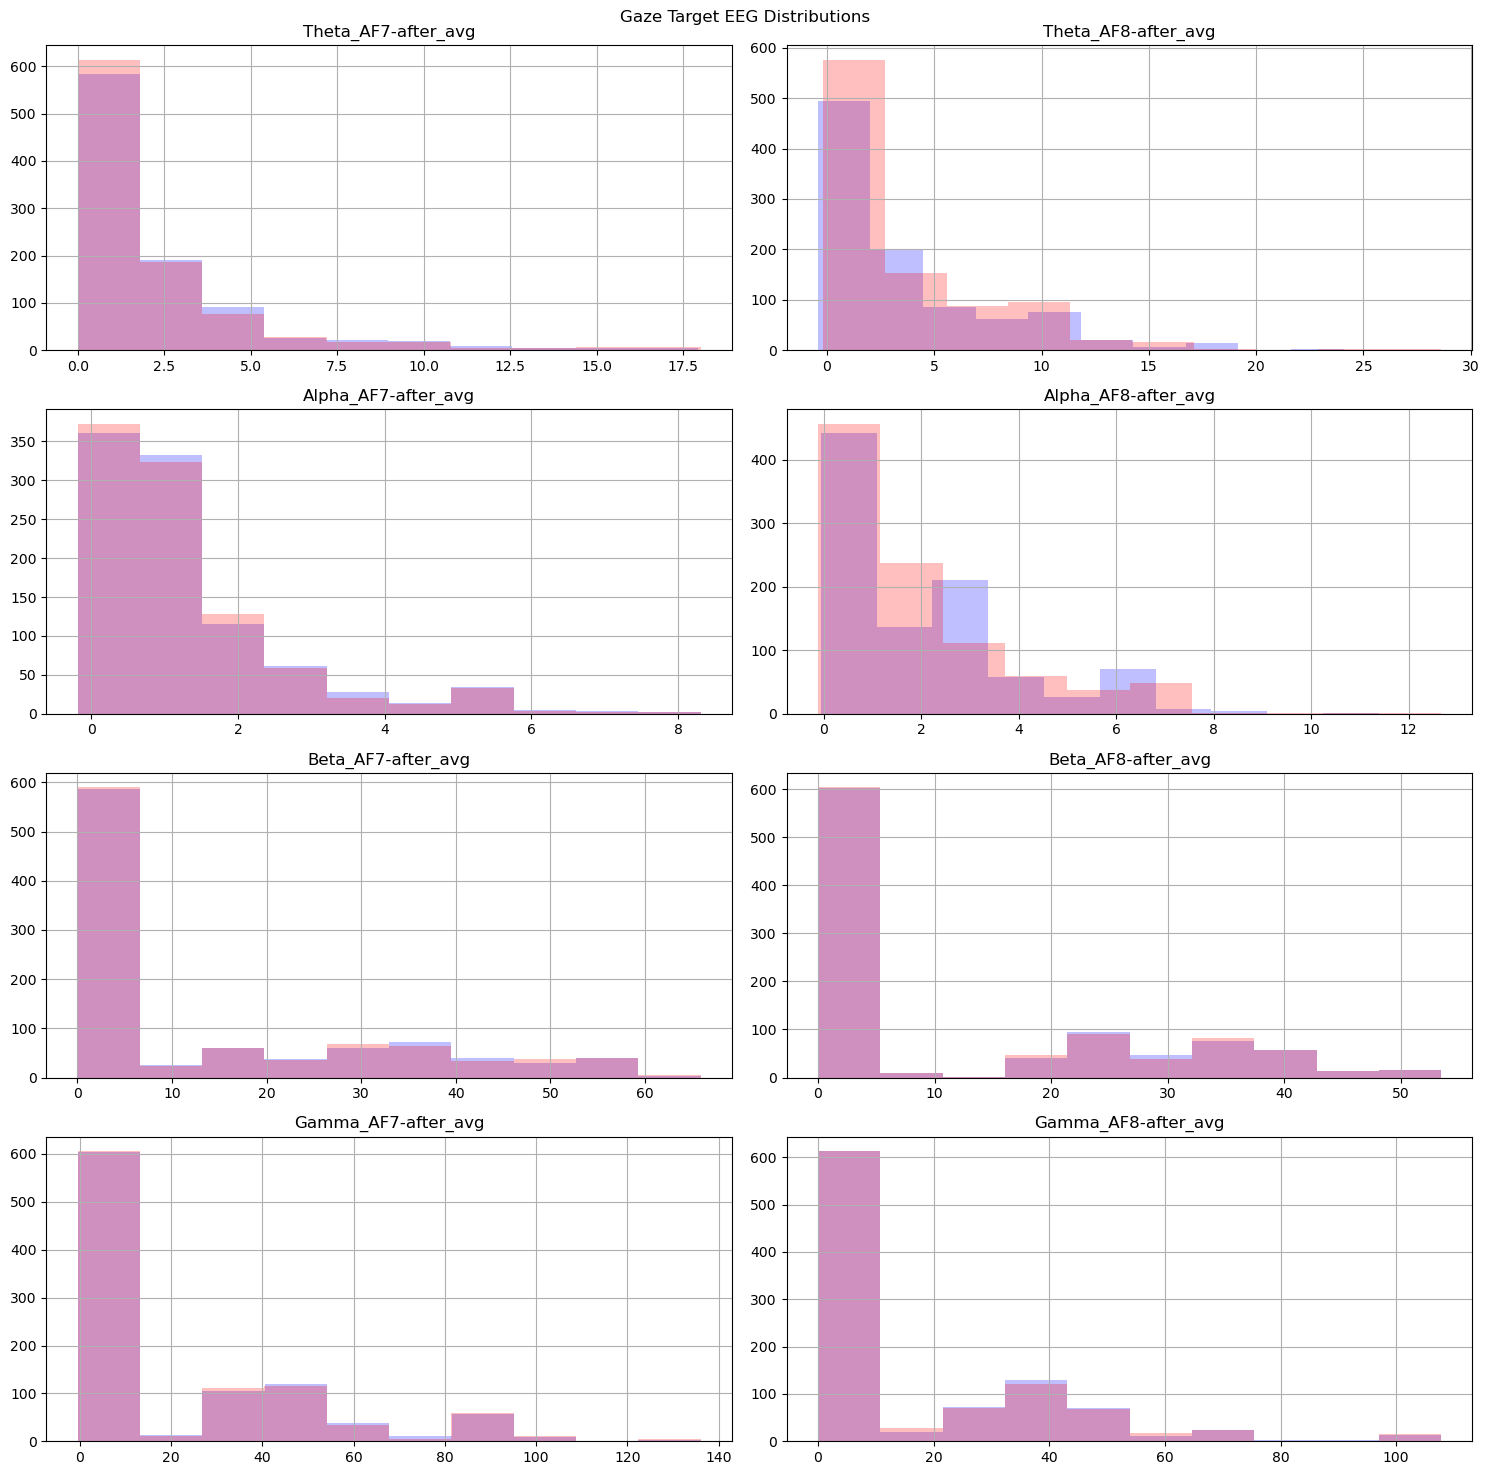

**Points Polyserial: Target Types:**

--- **Theta_AF7-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.05409413218601168|0.09426079014356176||
|PedestrianSignal|-0.03326423947583625|0.30370480185272875||
|Vehicle|0.0035936706371695656|0.9115490185298701||
|VehicleSignal|-0.01755835232368147|0.5872737306361057||


--- **Theta_AF7-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.04604381999300383|0.15443969806677899||
|PedestrianSignal|0.013132169567159863|0.6847806860836163||
|Vehicle|-0.03739529722127578|0.24754347621068698||
|VehicleSignal|0.0030916038794023626|0.9238658204778026||


--- **Theta_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.038860044293422664|0.22949406566796754||
|PedestrianSignal|-0.0075397977200657215|0.815709189061327||
|Vehicle|-0.01993096810564783|0.537795096084083||
|VehicleSignal|0.0042241187626942435|0.8961130906885691||


--- **Theta_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|0.009878263679522898|0.7600949607830887||
|PedestrianSignal|0.009412133237324358|0.771092275823114||
|Vehicle|0.004459947495169599|0.890348804122126||
|VehicleSignal|-0.024552104719785688|0.4478234946895479||


...

--- **Beta_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.020962297520478877|0.5169589201621874||
|PedestrianSignal|0.02435170896718466|0.45153925285936225||
|Vehicle|-0.0806565902319571|0.01251575985989696|*|
|VehicleSignal|0.11284892997633657|0.0004661737332454693|*|


--- **Gamma_AF7-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.03822567895159419|0.2371928872483736||
|PedestrianSignal|0.021766381084263035|0.5010084183788039||
|Vehicle|-0.0631463259334053|0.05071580068450512||
|VehicleSignal|0.1041392955752378|0.0012472563562276572|*|


--- **Gamma_AF7-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.03779284155409449|0.2425494031826637||
|PedestrianSignal|0.025490381440614024|0.43065842958908274||
|Vehicle|-0.06868319226212306|0.03353758151932794|*|
|VehicleSignal|0.1082157207041807|0.0007938485947846232|*|


--- **Gamma_AF8-prior_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.026883682026416677|0.40588541975446046||
|PedestrianSignal|0.03677058444477309|0.25553572591862955||
|Vehicle|-0.05087365367114109|0.1155839027178805||
|VehicleSignal|0.061077473459398686|0.05879269565044255||


--- **Gamma_AF8-after_avg** ---
|Target Type|Statistic|PValue|Significant?|
|:-|:-:|:-:|:-:|
|Pedestrian|-0.03092054883375017|0.3390627450819681||
|PedestrianSignal|0.046130377980714836|0.15366543972661986||
|Vehicle|-0.06518926219641304|0.04367234954162528|*|
|VehicleSignal|0.07626865447769564|0.018226097431128498|*|


In [89]:
_PARTICIPANTS_DIRS = [
    #'../samples/P0',
    '../samples/P1',
    #'../samples/P2',
    '../samples/P3',
    '../samples/P4',
    '../samples/P5',
    #'../samples/P6'
]

aggregate_gaze_eeg_dfs = []
for pdir in _PARTICIPANTS_DIRS:
    dfs = ProcessParticipant(pdir)
    aggregate_gaze_eeg_dfs.append(dfs['gaze_eeg'])
aggregate_gaze_eeg_df = pd.concat(aggregate_gaze_eeg_dfs, ignore_index=True, axis=0)
print(aggregate_gaze_eeg_df['target_type'].unique())

iDisplay(Markdown('## Aggregate Results'))
TestNormality_Omni(aggregate_gaze_eeg_df, _FREQUENCY_BANDS, _ELECTRODES, display_distributions=True, save_figname='../samples/distributions.png')
"""
iDisplay(Markdown("**Aggregate One Way ANOVA: Target Types:**"))
for col in freq_band_colnames:
    OneWayAnova_TargetType(aggregate_gaze_eeg_df, f'{col}-prior_avg')
    OneWayAnova_TargetType(aggregate_gaze_eeg_df, f'{col}-after_avg')
iDisplay(Markdown("**Aggregate One Way ANOVA: Target States:**"))
for col in freq_band_colnames:
    OneWayAnova_TargetState(aggregate_gaze_eeg_df, f'{col}-prior_avg')
    OneWayAnova_TargetState(aggregate_gaze_eeg_df, f'{col}-after_avg')
"""
iDisplay(Markdown("**Points Polyserial: Target Types:**"))
for col in freq_band_colnames:
    PointsPolyserial(aggregate_gaze_eeg_df, f'{col}-prior_avg', 'target_type')
    PointsPolyserial(aggregate_gaze_eeg_df, f'{col}-after_avg', 'target_type')


# 4. Misc

In [84]:
def PlotEEG(df, frequencies, electrodes, colors, trial_df=None, suptitle:str='EEG', save_figname:str=None):
    # Let's display this participant's EEG data
    fig, axes = plt.subplots(nrows=len(frequencies), ncols=len(electrodes))
    fig.set_figheight(15)
    fig.set_figwidth(10)
    fig.suptitle(suptitle)

    for i in range(len(frequencies)):
        color = colors[i]
        freq = frequencies[i]
        for j in range(len(electrodes)):
            electrode = electrodes[j]
            colname = f"{freq}_{electrode}_normalized"
            title = f"{freq} {electrode} (Normalized)"
            ax = df.plot.line(x='unix_ms',y=colname, ax=axes[i,j], color=color, title=title)
            ax.legend_ = None
            
            if trial_df is not None:
                for index, row in trial_df.iterrows():
                    if index == 0: continue
                    ax.axvline(x=row['start_unix'], color='black')
                    ax.axvline(x=row['end_unix'], color='gray')

    plt.tight_layout()
    if save_figname is not None:
        plt.savefig(save_figname, bbox_inches="tight", pad_inches=0.1)
    plt.show()

## _Example:_

## Processing ../samples/P6

Initial End Frame: 2470
Initial End Timestamp: 65.26667
Initial End Unix MS: 1743103313740
Session End Unix MS: 1743103505881


---

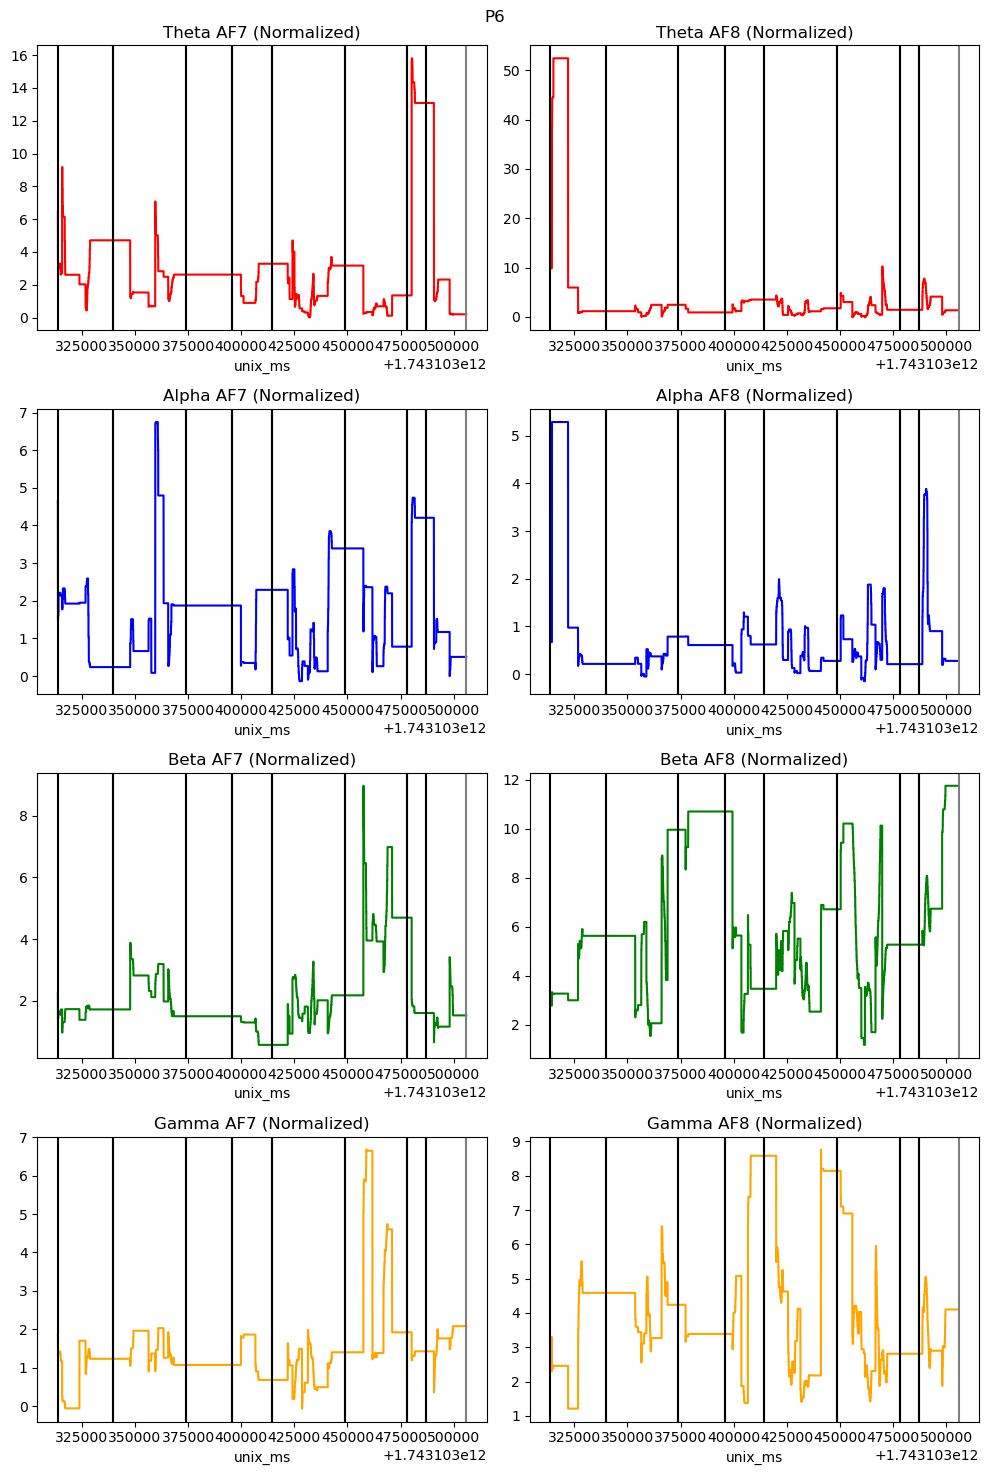

In [88]:
iDisplay(Markdown('## _Example:_'))

dfs = ProcessParticipant('../samples/P6', calculate_results=False)
PlotEEG(dfs['eeg'], _FREQUENCY_BANDS, _ELECTRODES, _FREQUENCY_COLORS, trial_df=dfs['trial'], suptitle='P6')